In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random

class SocialNetowrk():
    def __init__(self, n=100, k=1):
        self.n=n
        self.k=k
        self.pops = [0]*4
        Insample = nx.barabasi_albert_graph(n, k)        
        InAmatrix = self.weight_Amatrix_Poisson(np.triu(nx.to_numpy_array(Insample)))
        
        Outsample = nx.barabasi_albert_graph(n, k)        
        OutAmatrix = self.weight_Amatrix_Poisson(np.tril(nx.to_numpy_array(Outsample)))

        SampleAmatrix = InAmatrix + OutAmatrix
        
        self.G = nx.from_numpy_array(SampleAmatrix,create_using=nx.DiGraph)
        for id in self.G.nodes:
            self.G.nodes[id]["state"] = 0
            self.G.nodes[id]["immunity"] = 0
            self.G.nodes[id]["i2z"] = 0
            
    def weight_Amatrix_Poisson(self,Amatrix):
            for i,node in enumerate(Amatrix):

                neighbors = np.where(node == 1)[0]
                weights = np.zeros(self.n)

                poisson_vals = np.random.poisson(self.k, len(neighbors))
                weights[neighbors] = poisson_vals

                if weights.sum() == 0:
                    continue

                Amatrix[i] = weights / weights.sum()
            return Amatrix
    
    def show(self, ax=None):
        if ax == None:
            fig, axs = plt.subplots(3,figsize=(5,12))
        else:
            fig = ax.figure
            grid = fig.add_gridspec(3,1)
            axs = [fig.add_subplot(grid[0]), fig.add_subplot(grid[1]), fig.add_suboplot(grid[2])] 
        _, axs = plt.subplots(3,figsize=(5,12))

        layout = nx.spring_layout(self.G,seed=10)

        state_to_color = {
            0: "gray",
            1: "orange",
            2: "green",
            3: "brown",
        }

        colors = [state_to_color[self.G.nodes[i]["state"]] for i in self.G.nodes]

        nx.draw(self.G, pos=layout, ax=axs[0],
                node_size=35,
                node_color=colors)

        # Legend
        legend_items = [
            mpatches.Patch(color="gray", label="Healthy (0)"),
            mpatches.Patch(color="orange", label="Infected (1)"),
            mpatches.Patch(color="green", label="Zombie (2)"),
            mpatches.Patch(color="brown", label="Dead (3)")

        ]
        axs[0].legend(handles=legend_items)
        degree_dist = nx.degree_histogram(self.G)
        axs[1].plot([i for i,_ in enumerate(degree_dist)], degree_dist)
        axs[1].set_title("degree distribution")
        axs[1].set_xlabel("degree")
        axs[1].set_ylabel("frequency")
        axs[1].grid(True)

        axs[2].bar(
            x=[0,1,2,3],
            height=self.pops,
            color=["gray", "orange", "green", "brown"]
        )
    def show_degree_centrality(self):
        centrality = nx.degree_centrality(self.G)
        plt.grid(True)
        plt.title("degree centrality")
        plt.xlabel("node")
        plt.ylabel("centrality")
        plt.plot(centrality.keys(),centrality.values())
        plt.show()

class ZombieApocolypse(SocialNetowrk):
    def __init__(self,initial_infected_num=1,n=100,k=1):
        super().__init__(n,k)
        initial_infected = random.sample(range(self.n), initial_infected_num)

        for node in initial_infected:
            self.G.nodes[node]["state"] = 1
            self.G.nodes[node]["ttl"] = max(1, int(np.random.exponential(100)))
    
    def populations(self):
        self.pops = [0]*4
        for node in list(range(0,self.n)):
            self.pops[self.G.nodes[node].get("state",0)] += 1
    def show(self):
        super().show()

    def update_step(self):
        interaction_sequence = list(range(0,self.n))
        random.shuffle(interaction_sequence)
        for id in interaction_sequence:
            # dead -> no interaction

            node_state = self.G.nodes[id].get("state",0)

            if node_state == 3:
                continue
            
            if node_state == 2:
                self.G.nodes[id]["ttl"] -= 1
                if self.G.nodes[id]["ttl"] < 0:
                    self.G.nodes[id]["state"] = 3  # becomes dead
                    node_state = 3

                continue

            if node_state == 1:
                self.G.nodes[id]["ttl"] -= 1
                if self.G.nodes[id]["ttl"] <= 0:
                    self.G.nodes[id]["state"] = 2  # becomes zombie
                    node_state = 2  
                    self.G.nodes[id]["ttl"] = max(1, int(np.random.exponential(30)))

            valid_neighbors = [
                nbr for nbr in self.G[id]
                if self.G.nodes[nbr].get("state",0) < 2
            ]

            if not valid_neighbors:
                continue

            weights = [self.G[id][nbr].get("weight", 1) for nbr in valid_neighbors]

            choice = random.choices(population=valid_neighbors, weights=weights, k=1)[0]
            choice_state = self.G.nodes[choice].get("state",0)

            if node_state == 0 and choice_state == 1:
                new_state = int(np.random.choice([0,1]))
                self.G.nodes[id]["state"] = new_state
                if new_state == 1:
                    self.G.nodes[id]["ttl"] = max(1, int(np.random.exponential(3)))

            if node_state == 1 and choice_state == 0:
                new_state = int(np.random.choice([0,1]))
                self.G.nodes[choice]["state"] = new_state
                if new_state == 1:
                    self.G.nodes[choice]["ttl"] = max(1, int(np.random.exponential(3)))
                
            if node_state == 2 and choice_state == 0:
                # get second neighbors
                # 1-hop neighbors (direct friends)
                neighbors_1 = set(self.G[id])

                # 2-hop neighbors (friends of friends)
                neighbors_2 = set()
                for nbr in neighbors_1:
                    neighbors_2.update(self.G[nbr])

                # Combine both, remove self
                all_neighbors = (neighbors_1 | neighbors_2) - {id}

                valid_neighbors = [
                    nbr for nbr in all_neighbors
                    if self.G.nodes[nbr].get("state", 0) == 0
                ]

                choice = random.choices(population=valid_neighbors, k=1)[0]
                choice_state = self.G.nodes[choice].get("state",0)

                self.G.nodes[choice]["state"] = 1
                self.G.nodes[choice]["ttl"] = max(1, int(np.random.exponential(3)))

        self.populations()

In [2]:
import imageio.v2 as imageio
from tqdm import tqdm

def make_gif(zombie_sim:ZombieApocolypse, steps=20, outfile="zombie.gif"):
    frames = []

    for t in tqdm(range(steps)):
        plt.figure(figsize=(6, 8))
        zombie_sim.show()
        zombie_sim.update_step()
        plt.tight_layout()

        # Save a temporary PNG
        fname = f"frames/_frame_{t}.png"
        plt.title(t)
        plt.savefig(fname, dpi=150)
        plt.close()

        frames.append(imageio.imread(fname))

    imageio.mimsave(outfile, frames, fps=10)
    print(f"Saved GIF → {outfile}")

  0%|          | 0/100 [00:00<?, ?it/s]

  9%|▉         | 9/100 [00:28<04:49,  3.18s/it]/tmp/ipykernel_14771/261076180.py:48: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, axs = plt.subplots(3,figsize=(5,12))
 10%|█         | 10/100 [00:31<04:48,  3.21s/it]/tmp/ipykernel_14771/649073395.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 8))
100%|██████████| 100/100 [05:18<00:00,  3.19s/it]


Saved GIF → zombie.gif


<Figure size 600x800 with 0 Axes>

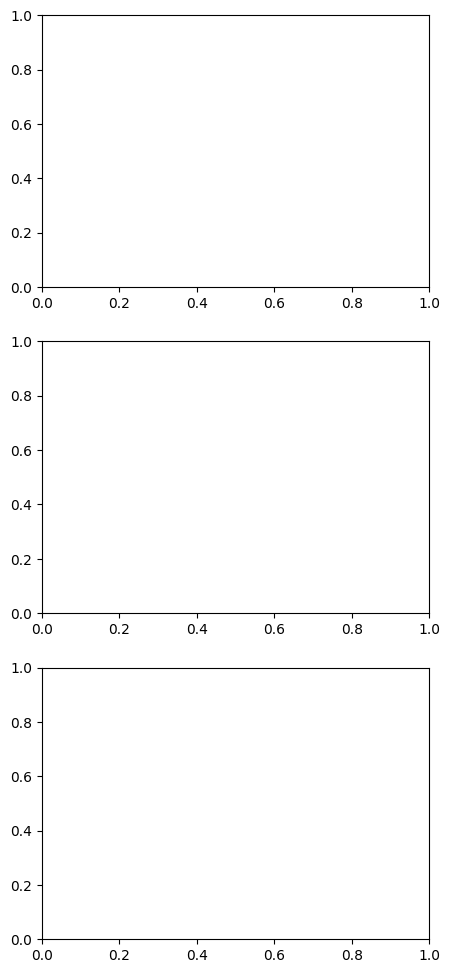

<Figure size 600x800 with 0 Axes>

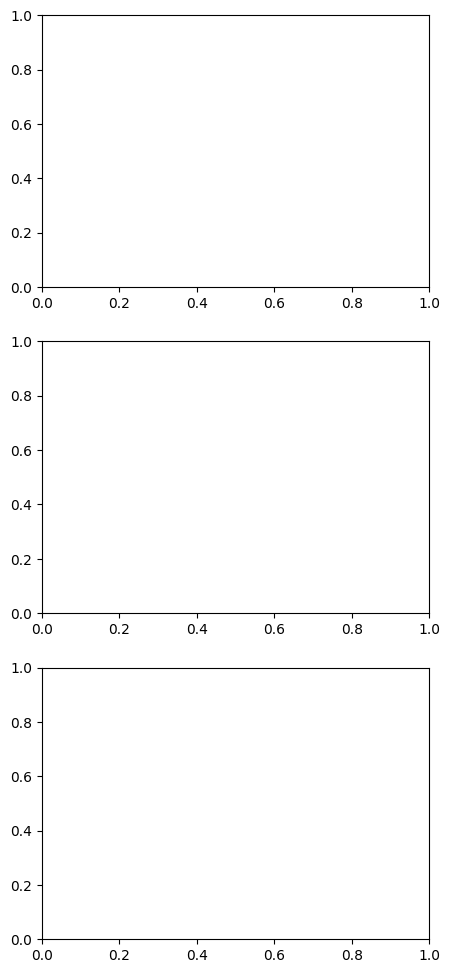

<Figure size 600x800 with 0 Axes>

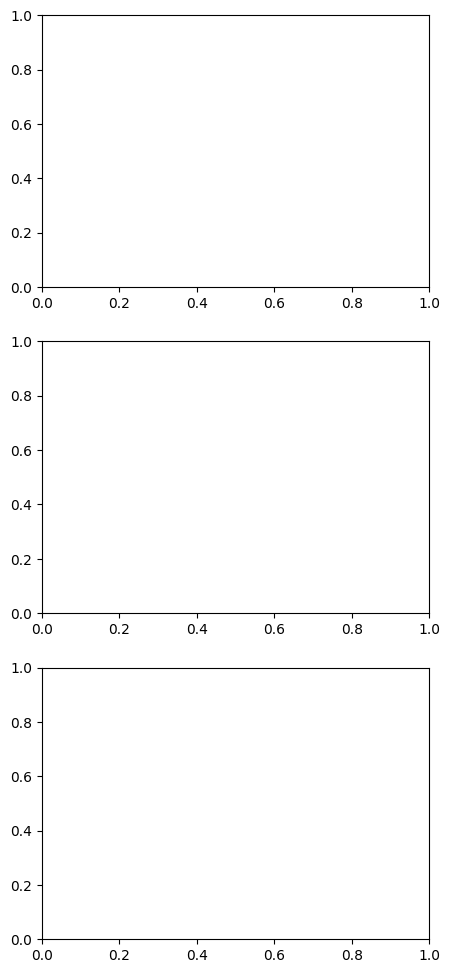

<Figure size 600x800 with 0 Axes>

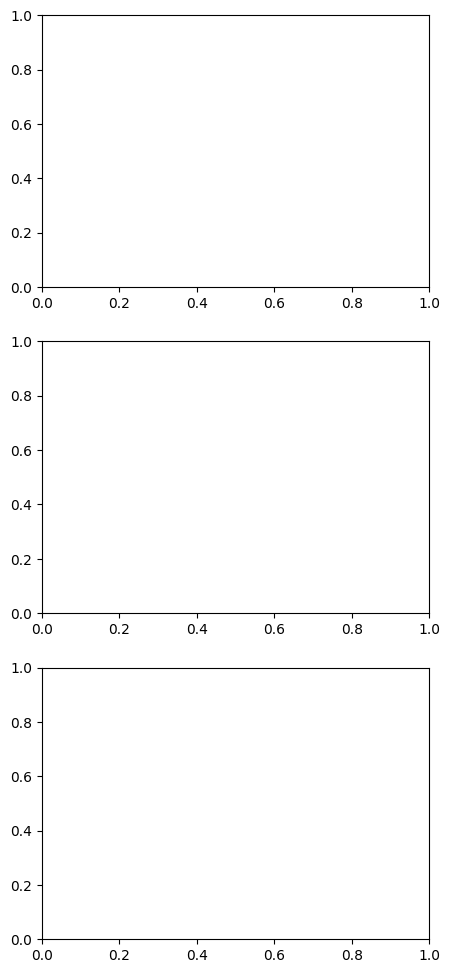

<Figure size 600x800 with 0 Axes>

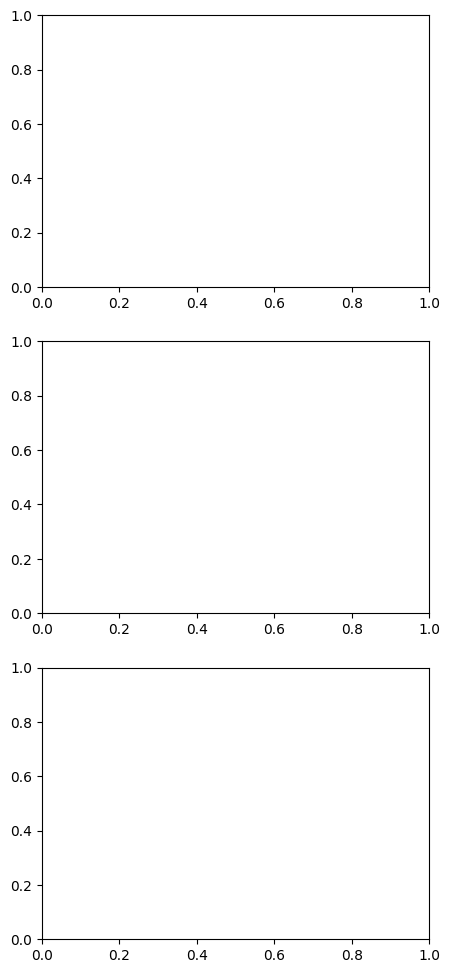

<Figure size 600x800 with 0 Axes>

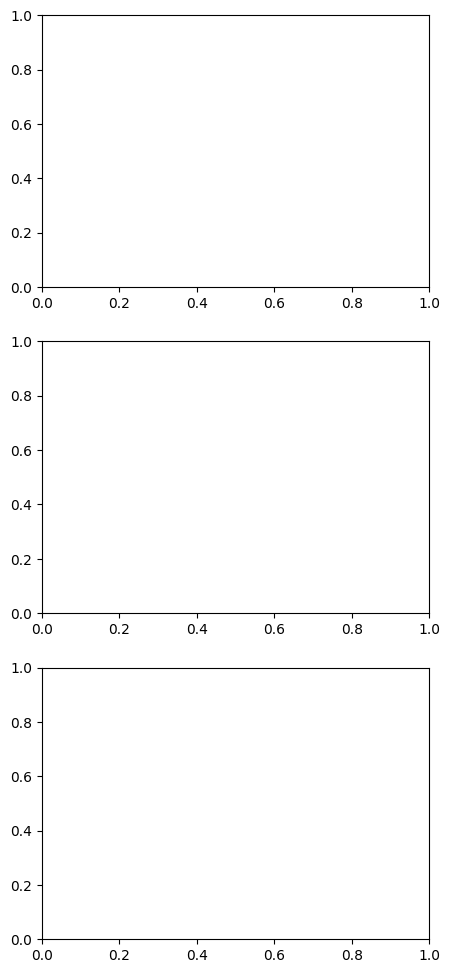

<Figure size 600x800 with 0 Axes>

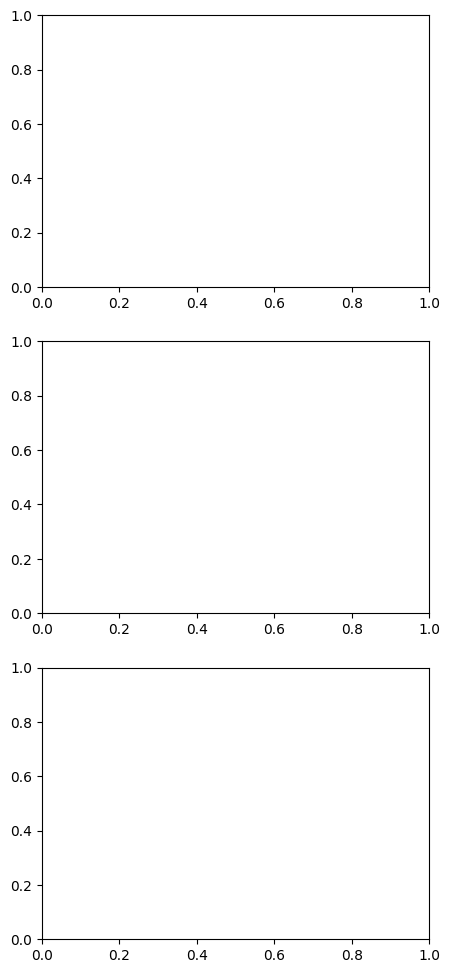

<Figure size 600x800 with 0 Axes>

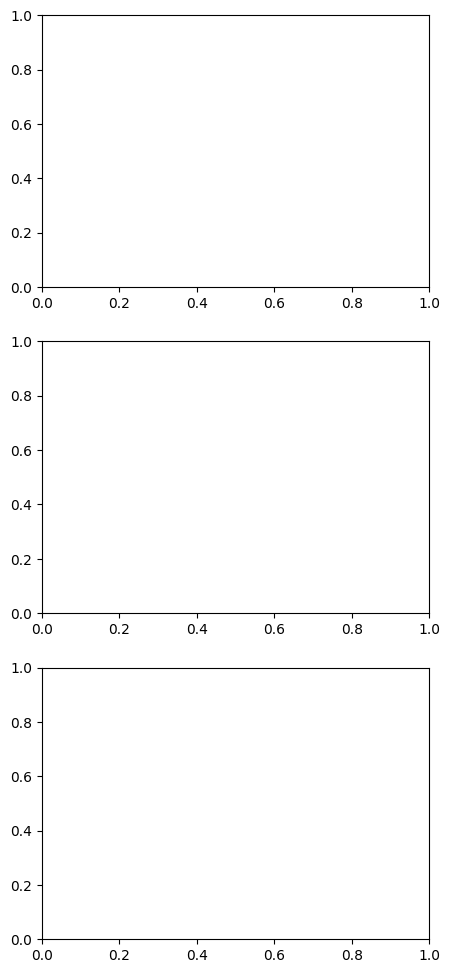

<Figure size 600x800 with 0 Axes>

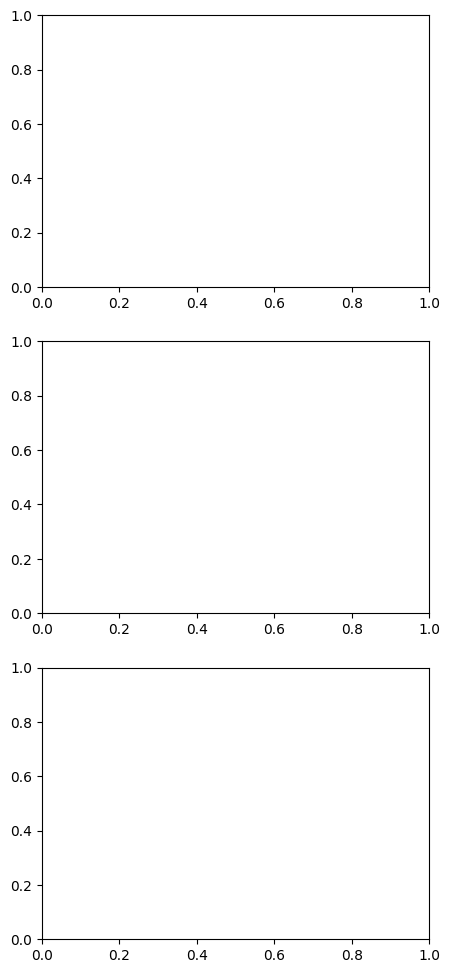

<Figure size 600x800 with 0 Axes>

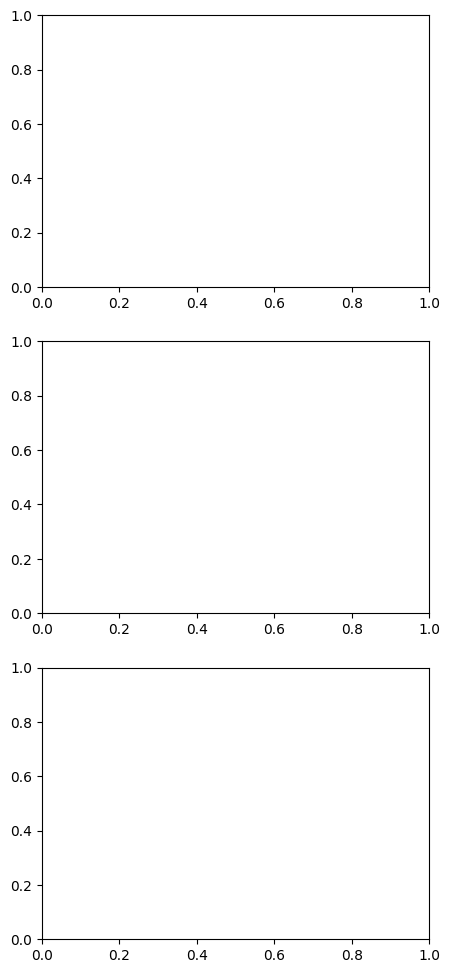

<Figure size 600x800 with 0 Axes>

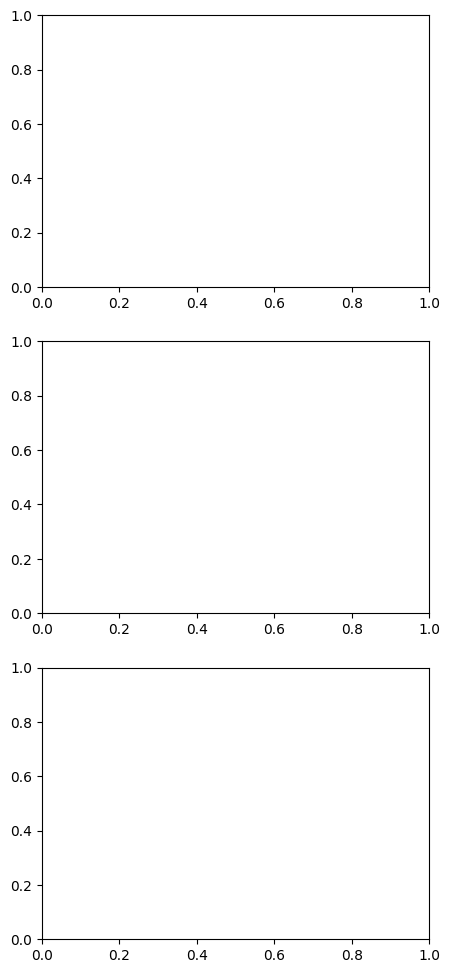

<Figure size 600x800 with 0 Axes>

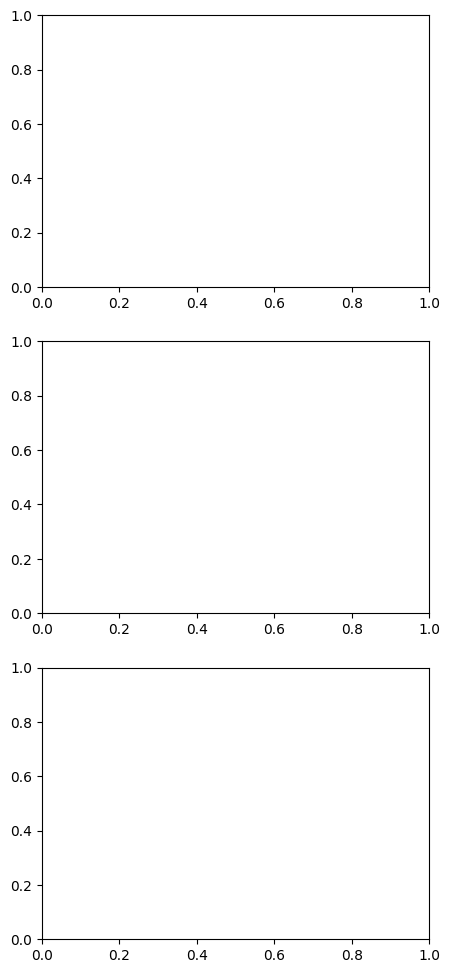

<Figure size 600x800 with 0 Axes>

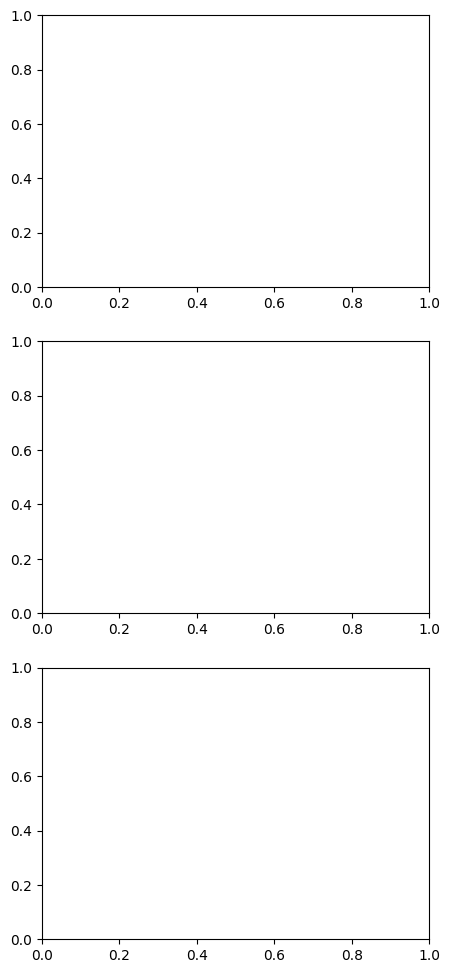

<Figure size 600x800 with 0 Axes>

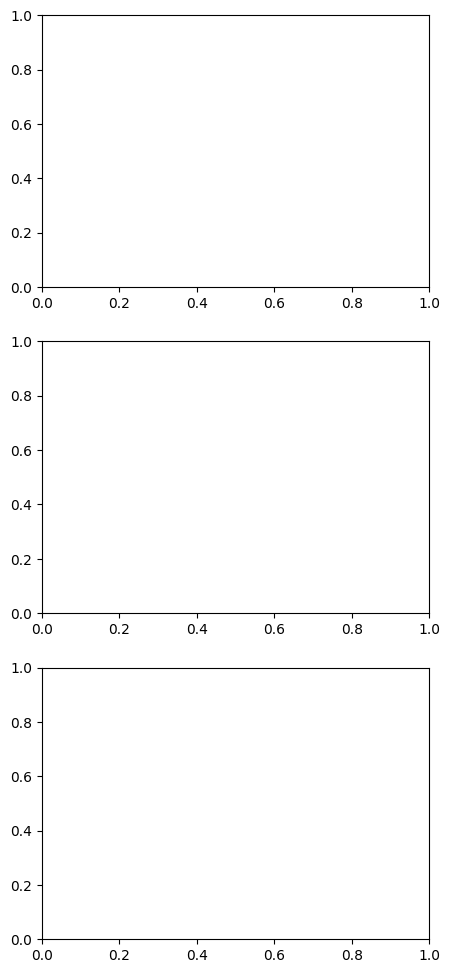

<Figure size 600x800 with 0 Axes>

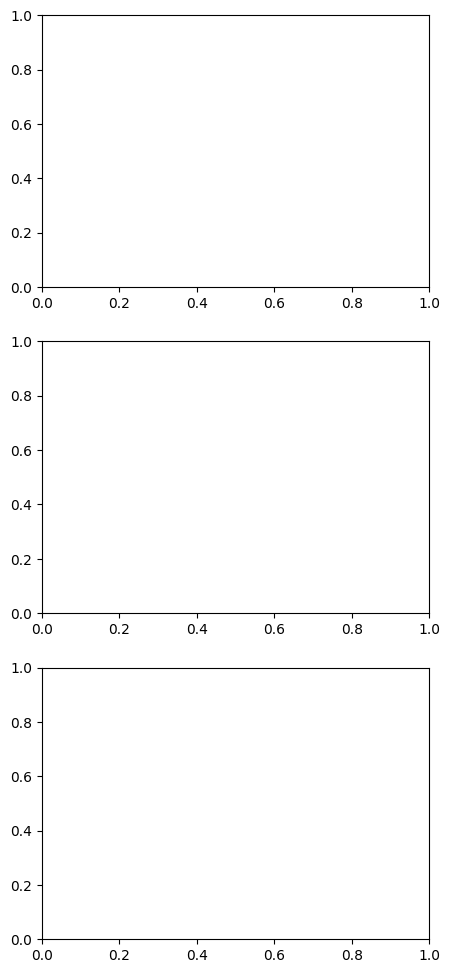

<Figure size 600x800 with 0 Axes>

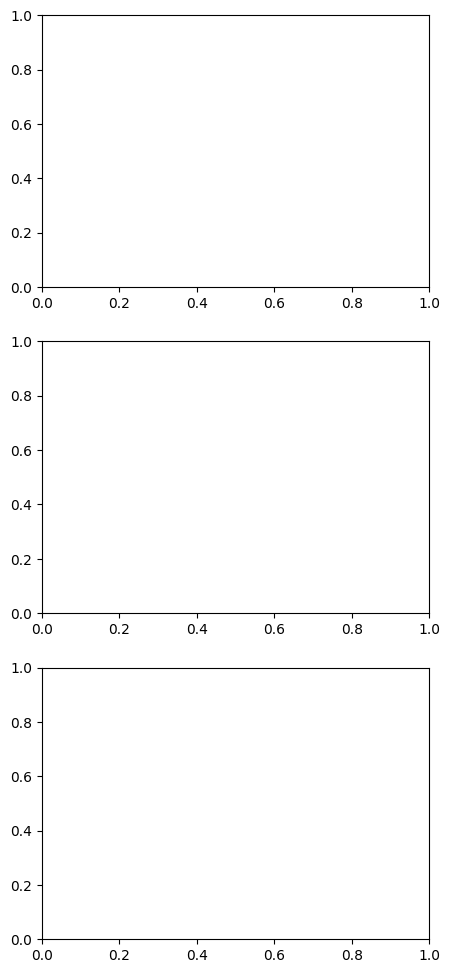

<Figure size 600x800 with 0 Axes>

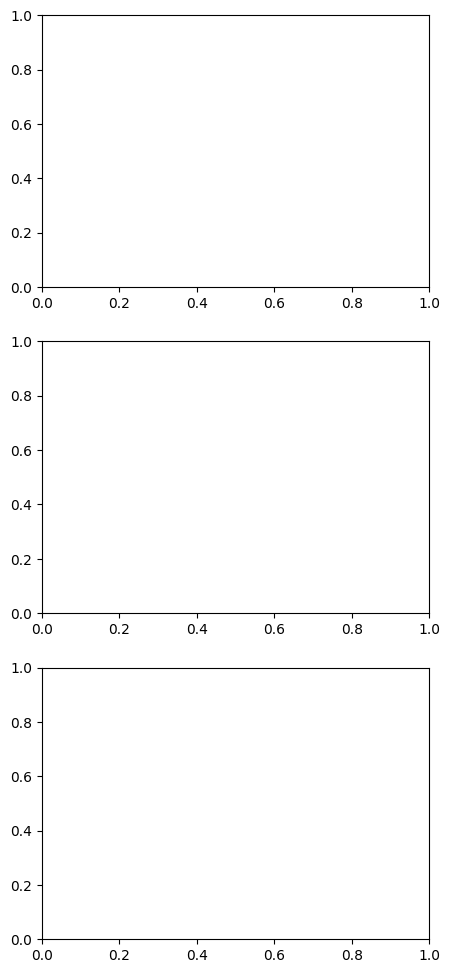

<Figure size 600x800 with 0 Axes>

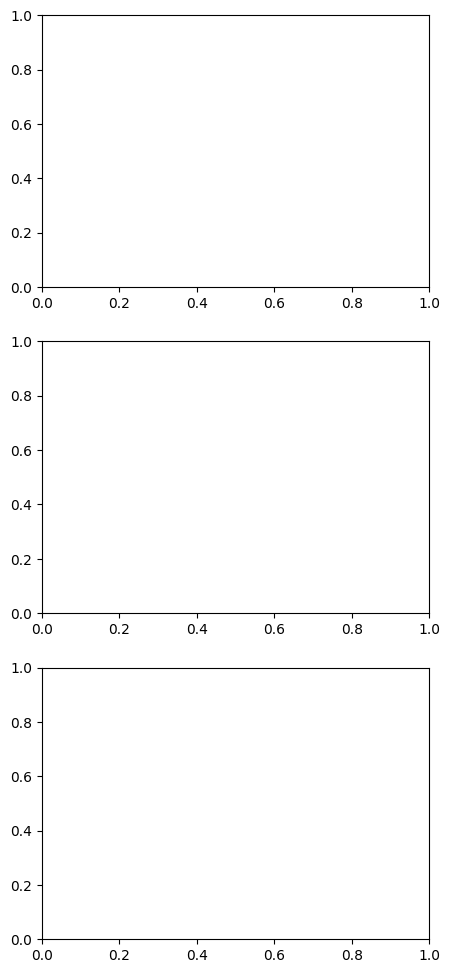

<Figure size 600x800 with 0 Axes>

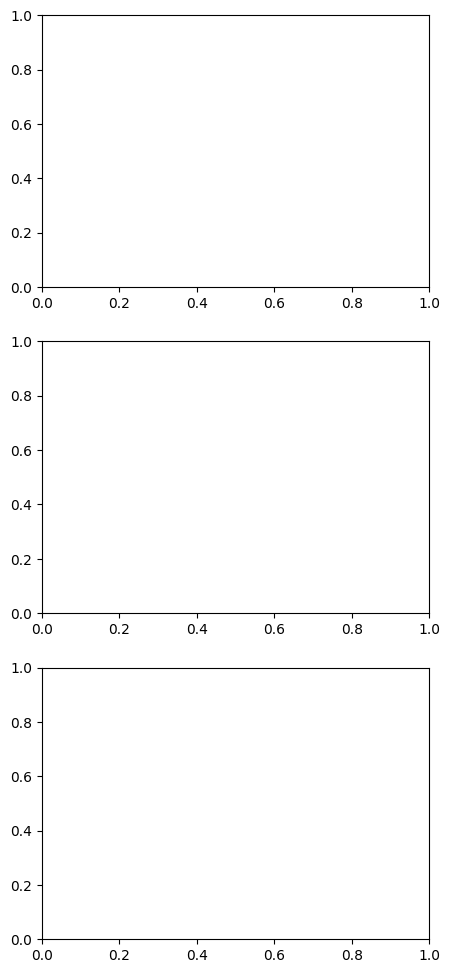

<Figure size 600x800 with 0 Axes>

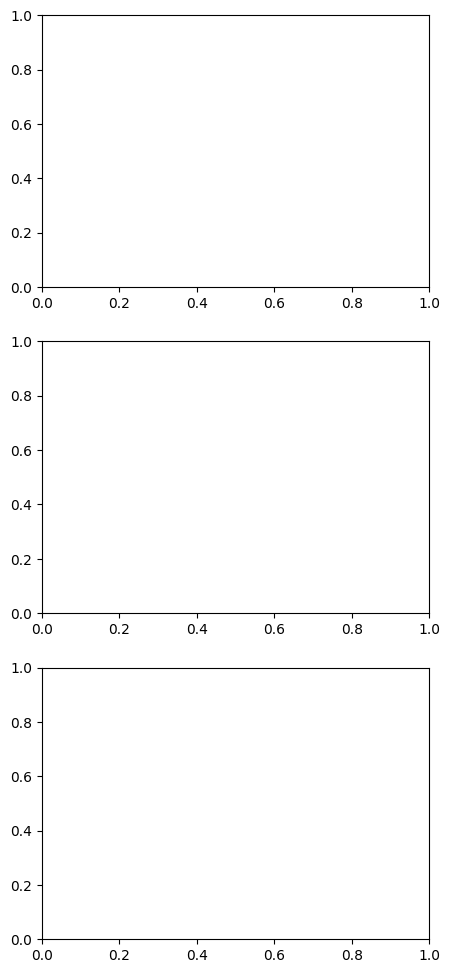

<Figure size 600x800 with 0 Axes>

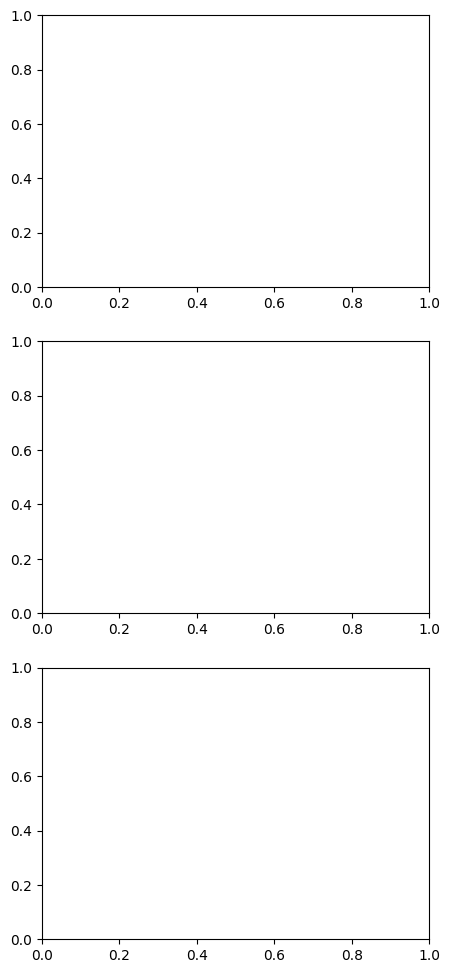

<Figure size 600x800 with 0 Axes>

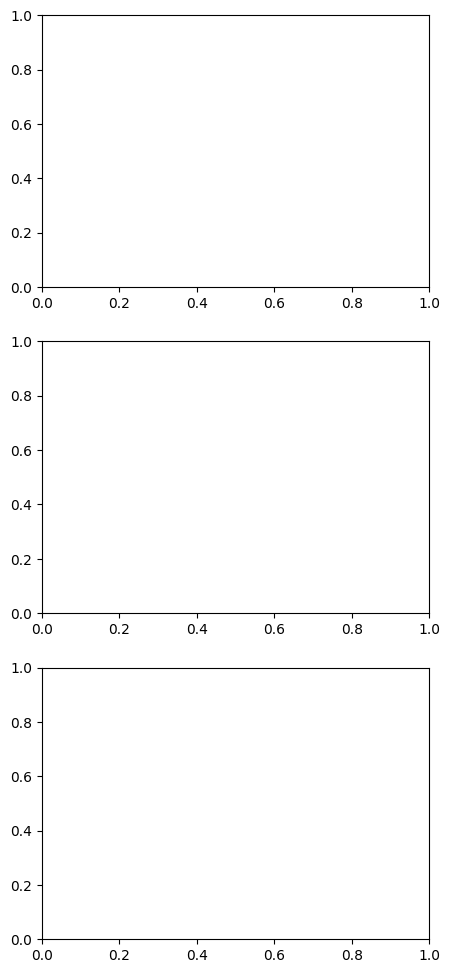

<Figure size 600x800 with 0 Axes>

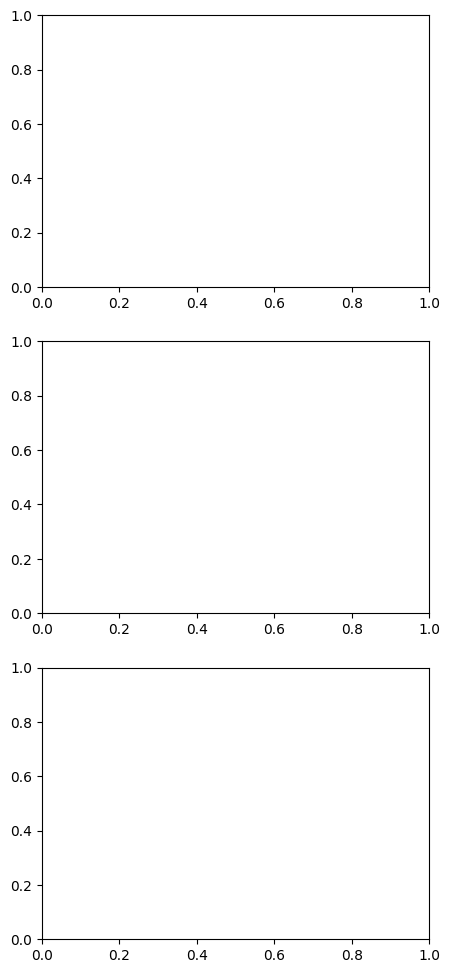

<Figure size 600x800 with 0 Axes>

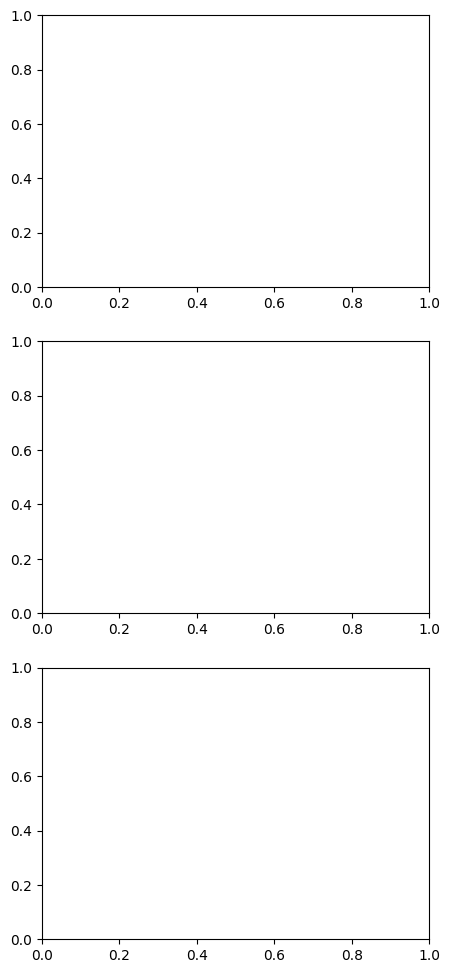

<Figure size 600x800 with 0 Axes>

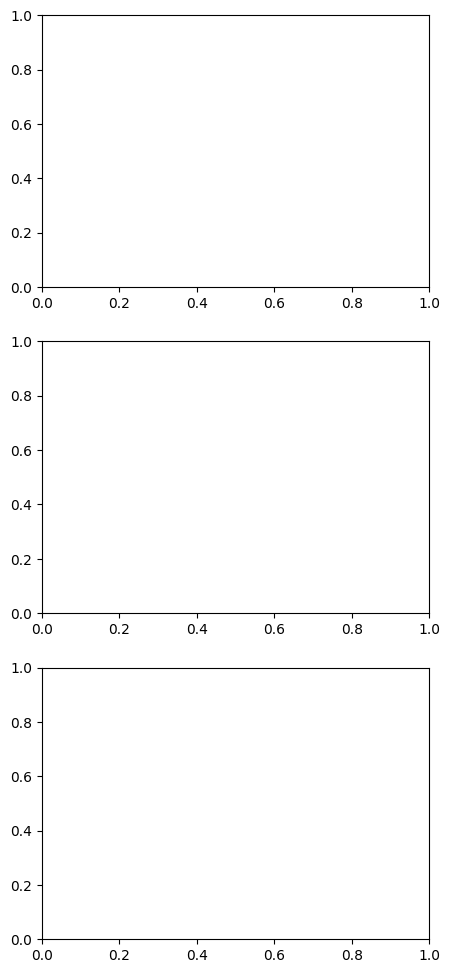

<Figure size 600x800 with 0 Axes>

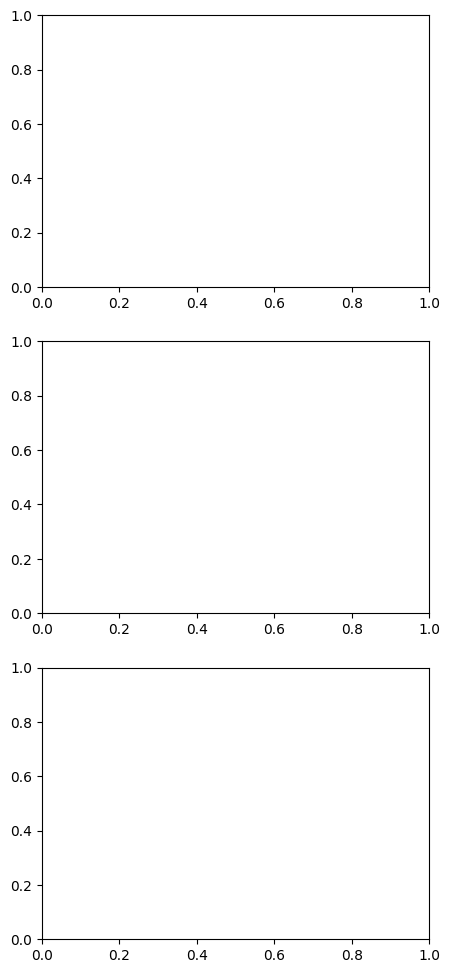

<Figure size 600x800 with 0 Axes>

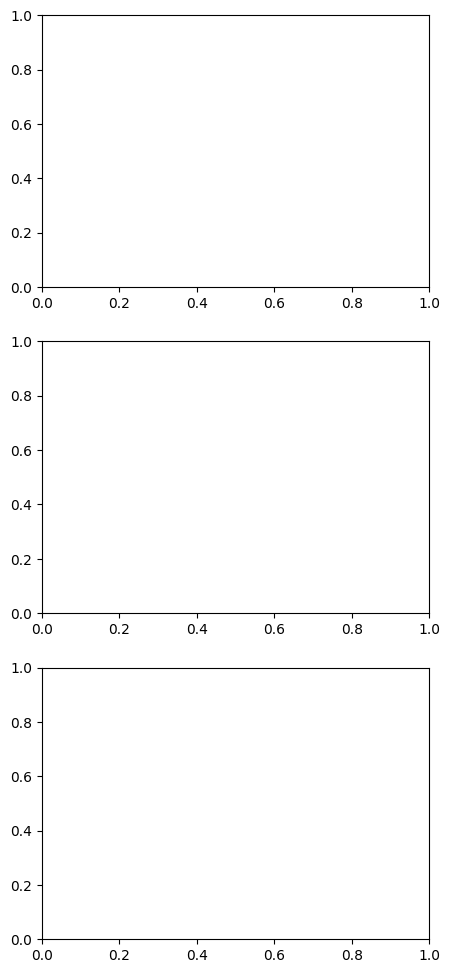

<Figure size 600x800 with 0 Axes>

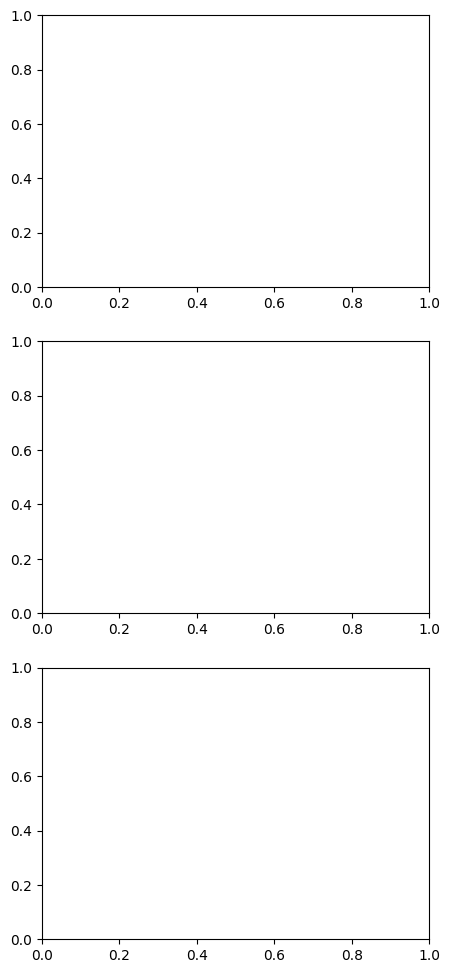

<Figure size 600x800 with 0 Axes>

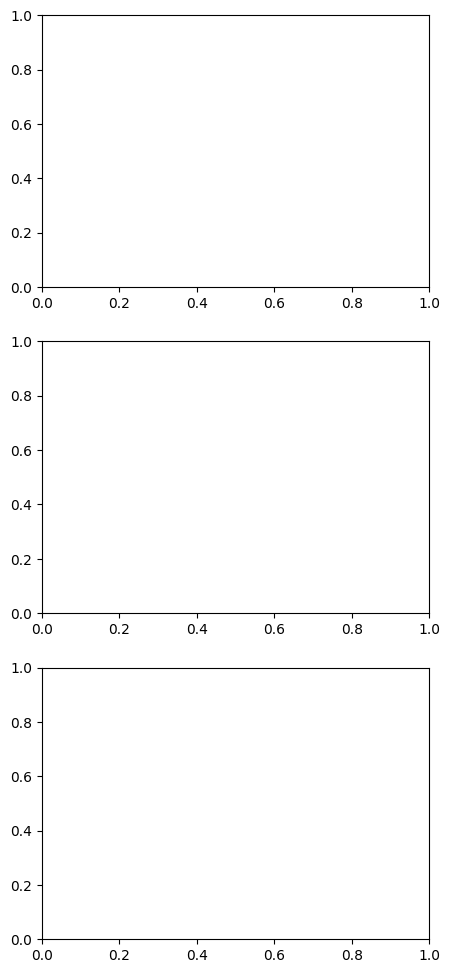

<Figure size 600x800 with 0 Axes>

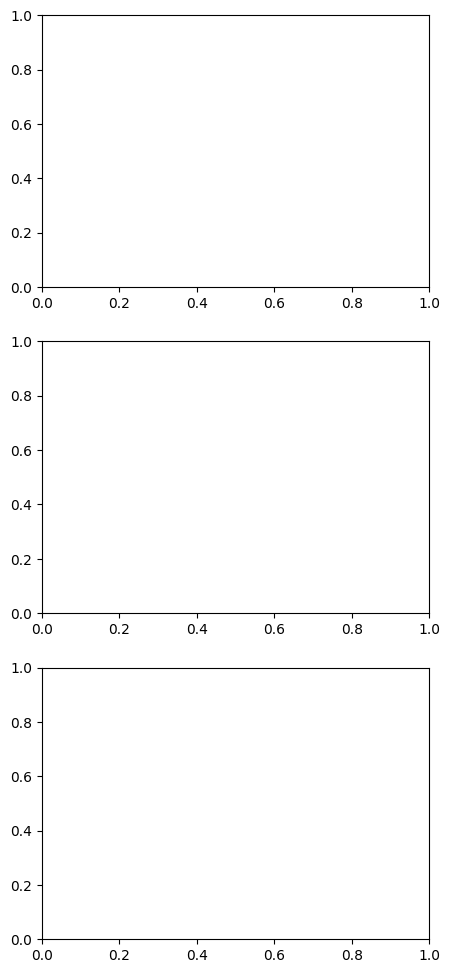

<Figure size 600x800 with 0 Axes>

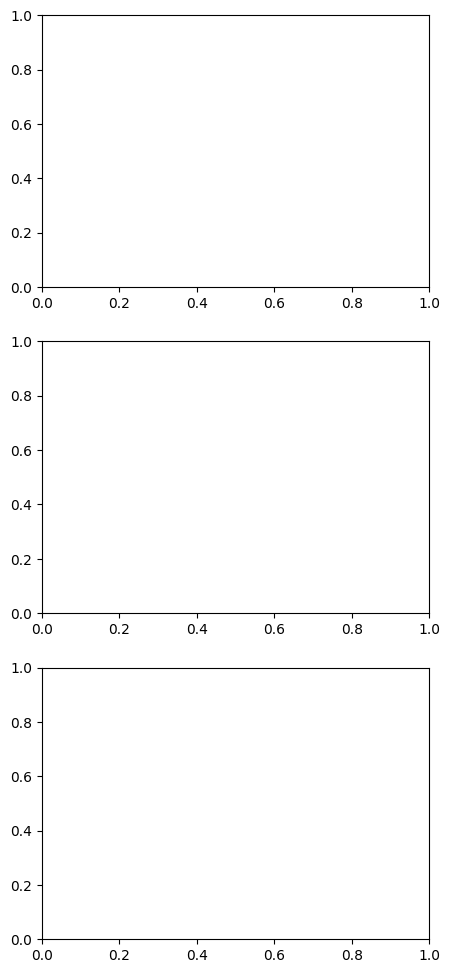

<Figure size 600x800 with 0 Axes>

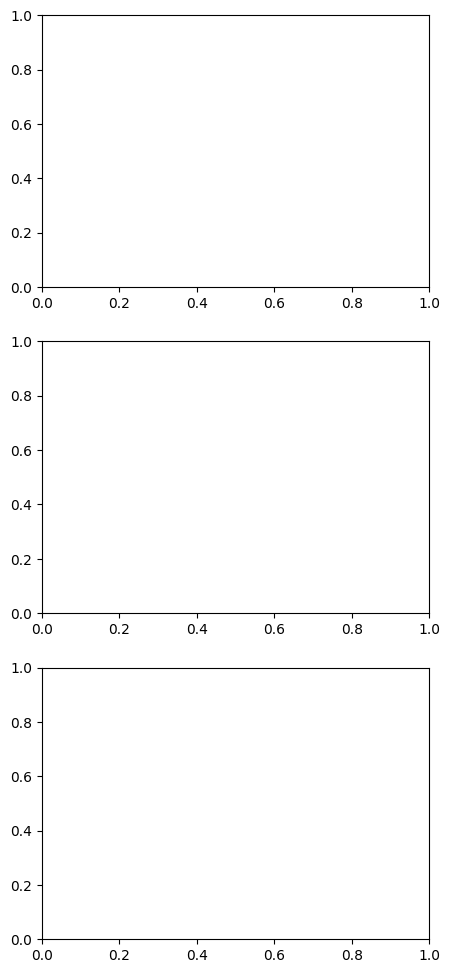

<Figure size 600x800 with 0 Axes>

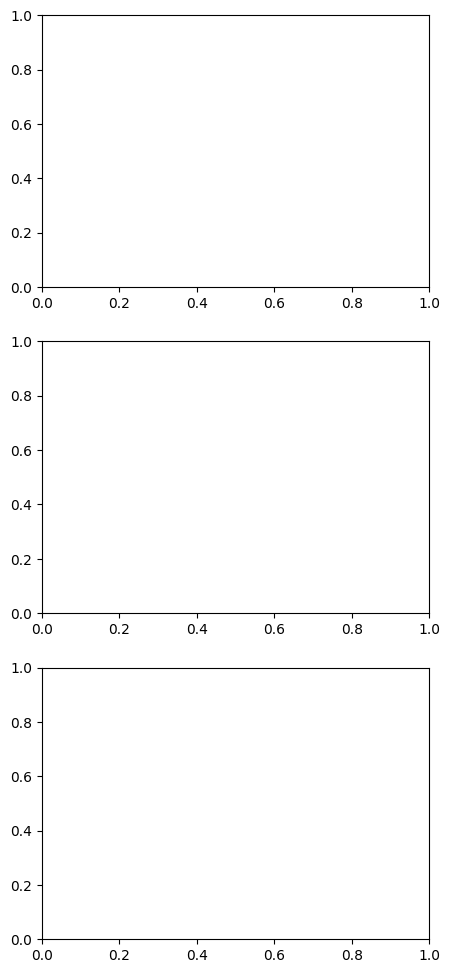

<Figure size 600x800 with 0 Axes>

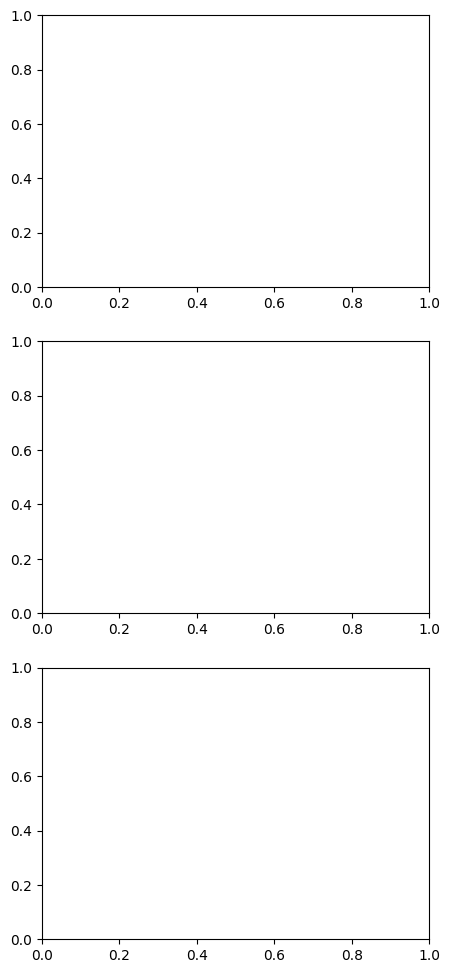

<Figure size 600x800 with 0 Axes>

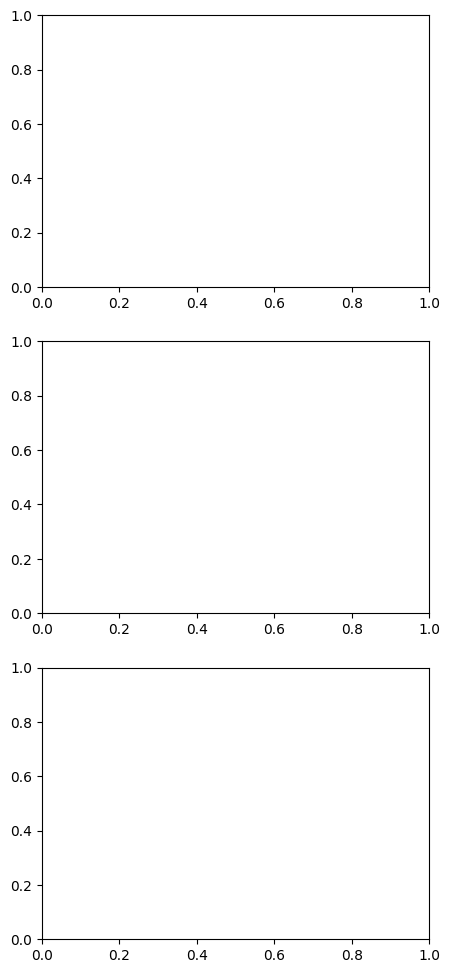

<Figure size 600x800 with 0 Axes>

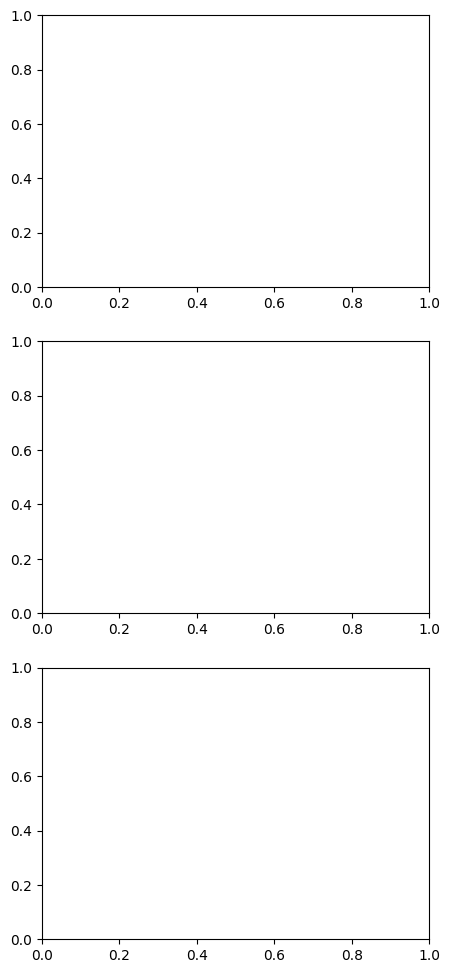

<Figure size 600x800 with 0 Axes>

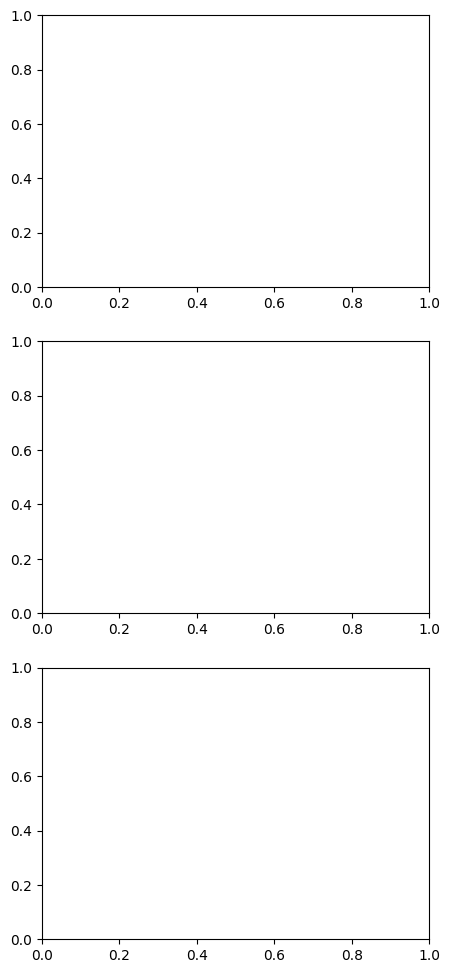

<Figure size 600x800 with 0 Axes>

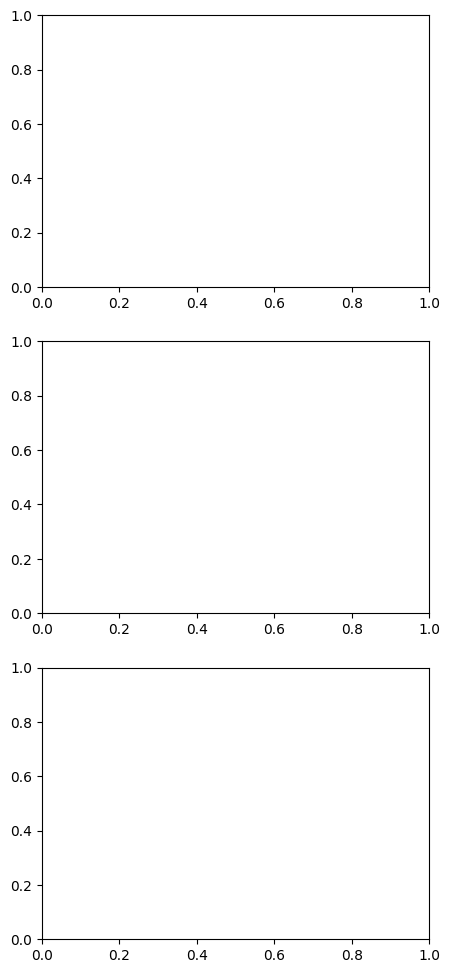

<Figure size 600x800 with 0 Axes>

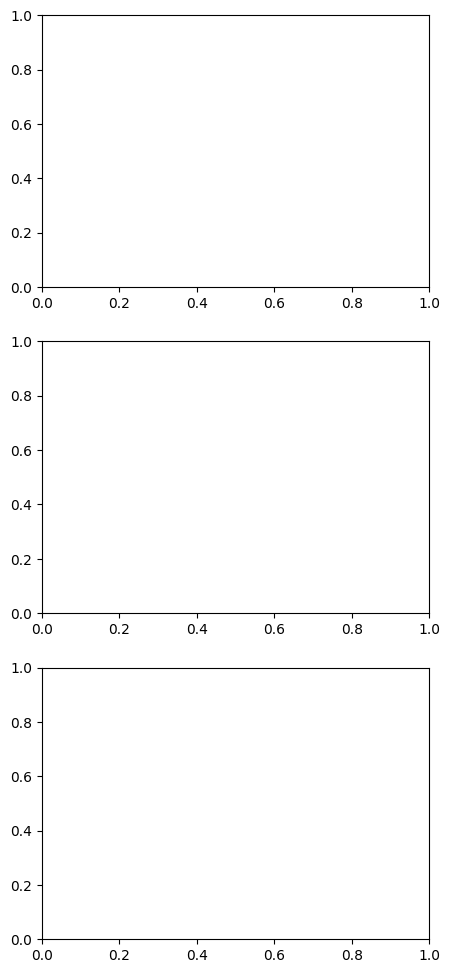

<Figure size 600x800 with 0 Axes>

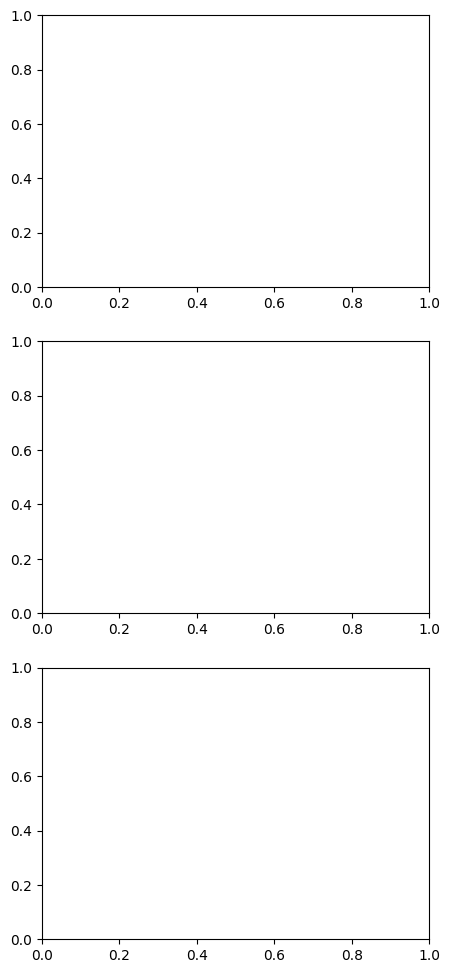

<Figure size 600x800 with 0 Axes>

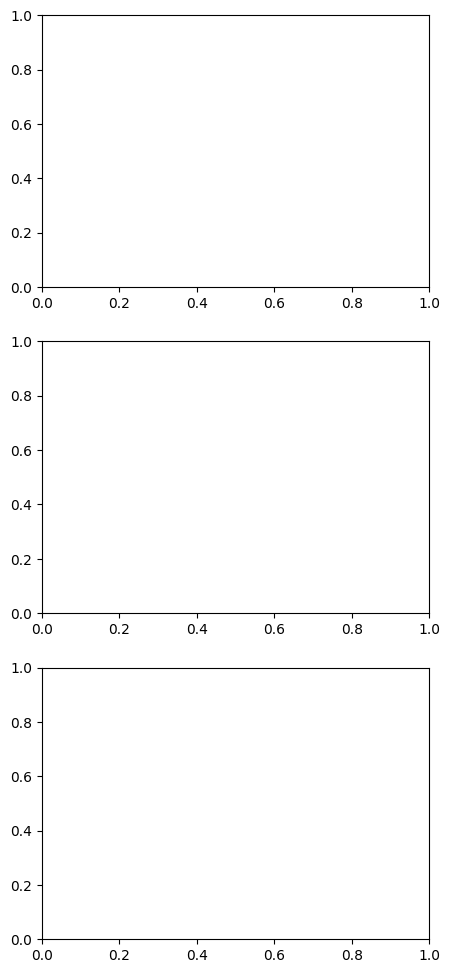

<Figure size 600x800 with 0 Axes>

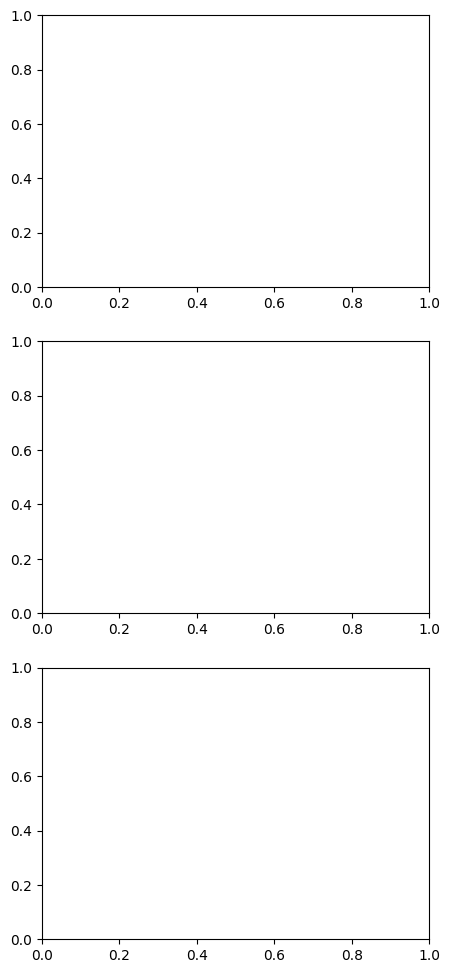

<Figure size 600x800 with 0 Axes>

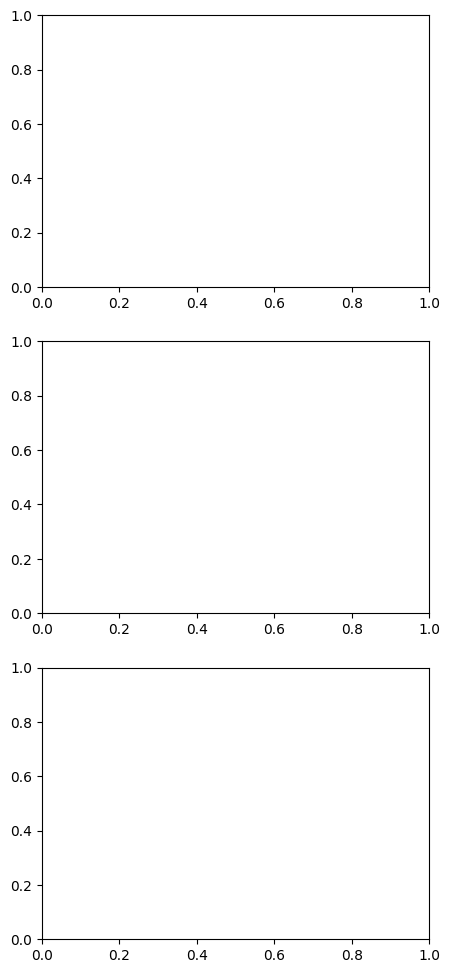

<Figure size 600x800 with 0 Axes>

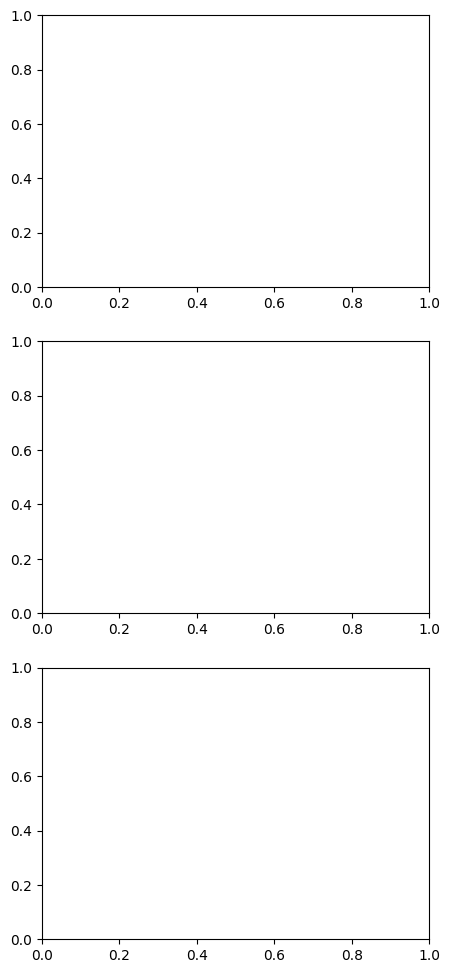

<Figure size 600x800 with 0 Axes>

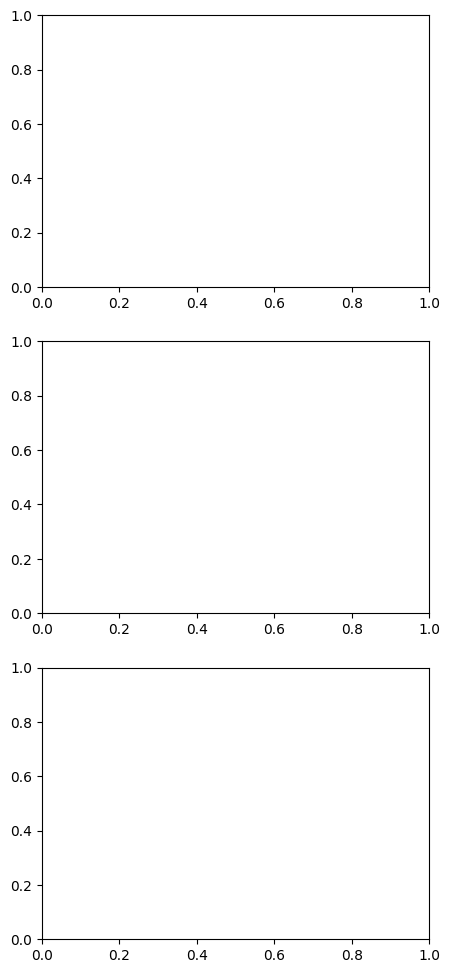

<Figure size 600x800 with 0 Axes>

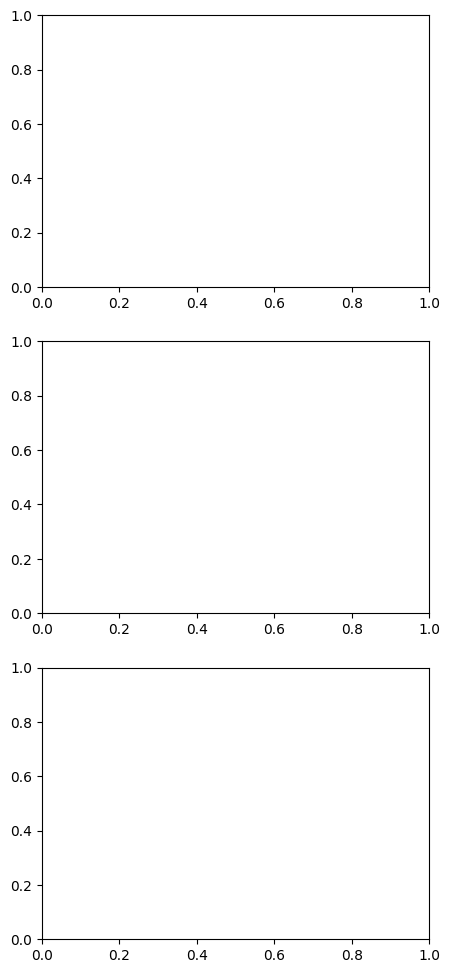

<Figure size 600x800 with 0 Axes>

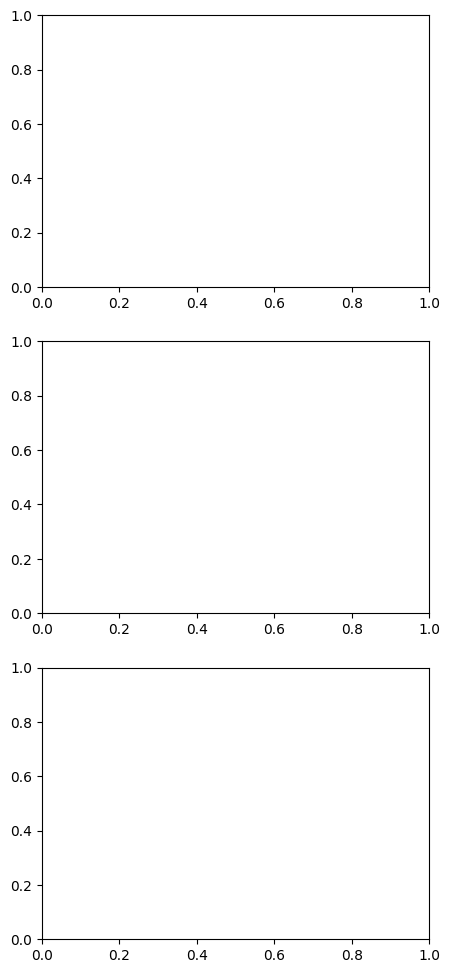

<Figure size 600x800 with 0 Axes>

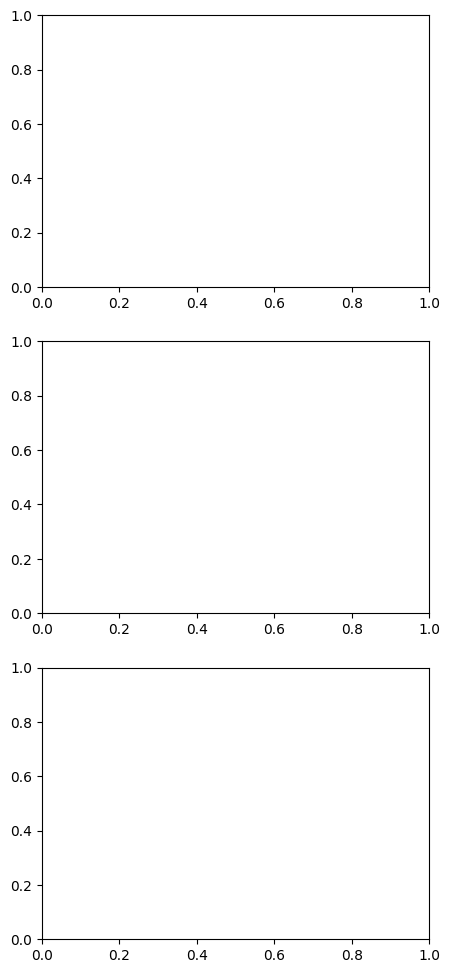

<Figure size 600x800 with 0 Axes>

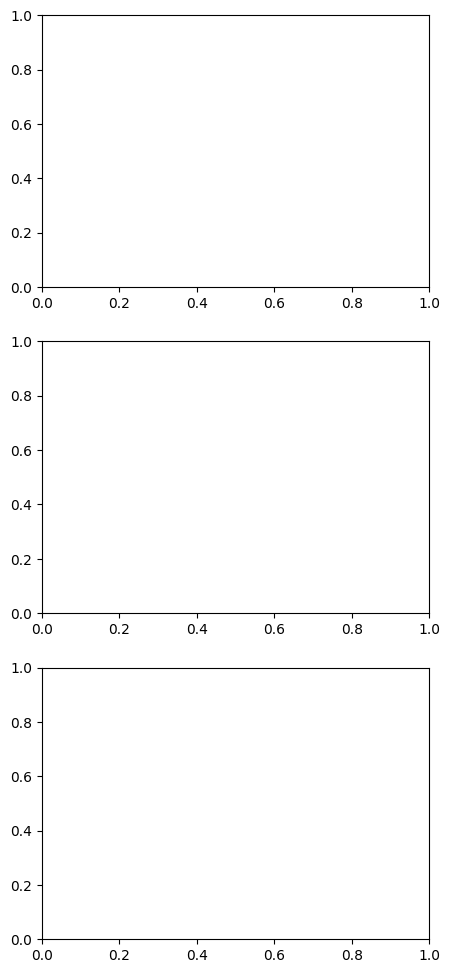

<Figure size 600x800 with 0 Axes>

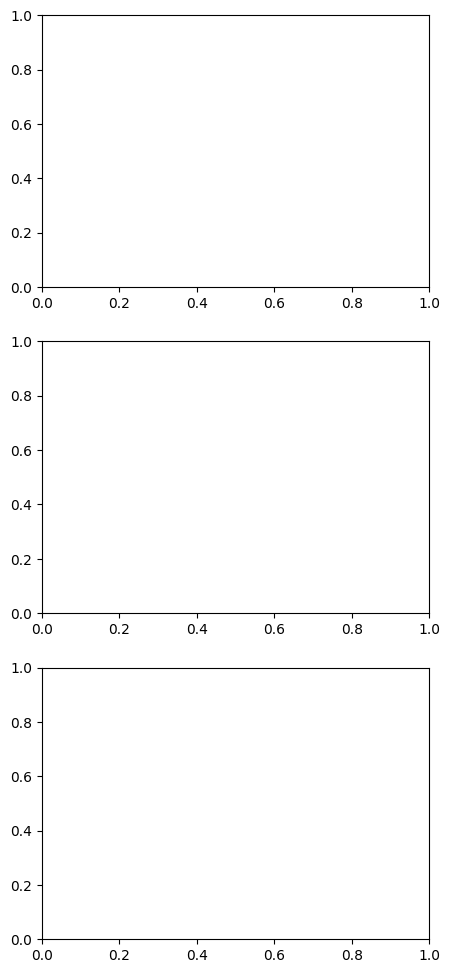

<Figure size 600x800 with 0 Axes>

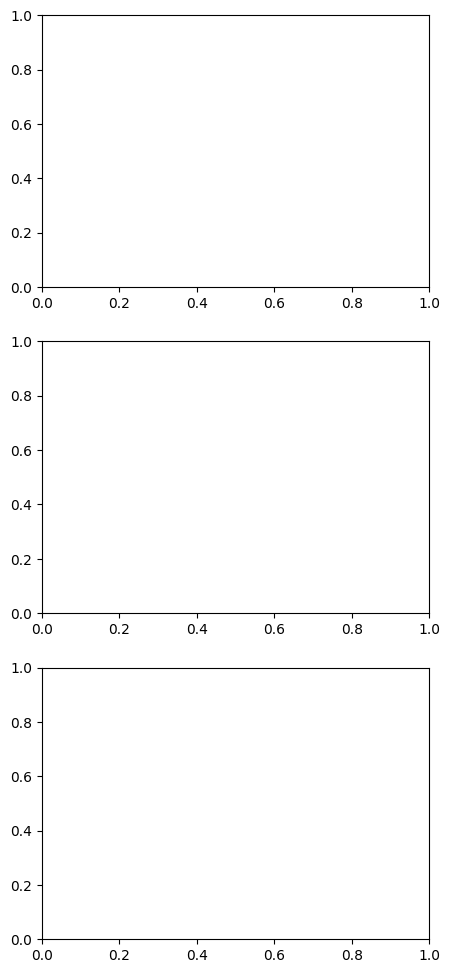

<Figure size 600x800 with 0 Axes>

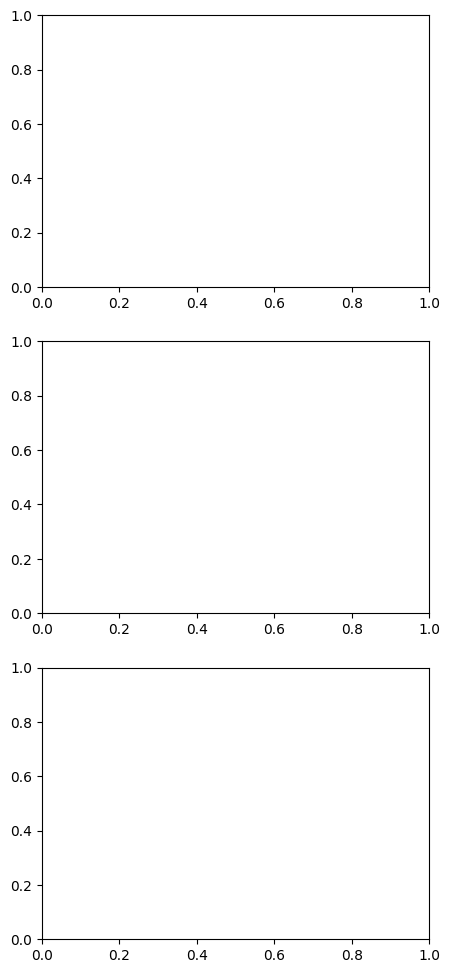

<Figure size 600x800 with 0 Axes>

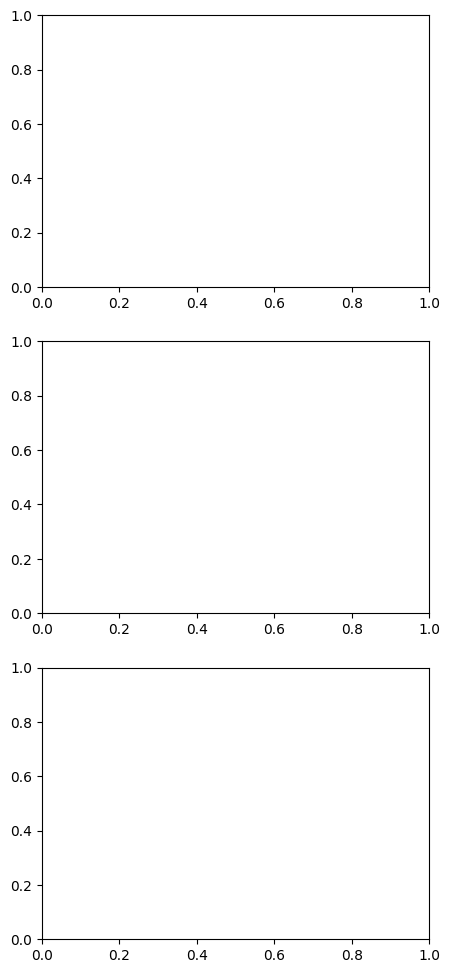

<Figure size 600x800 with 0 Axes>

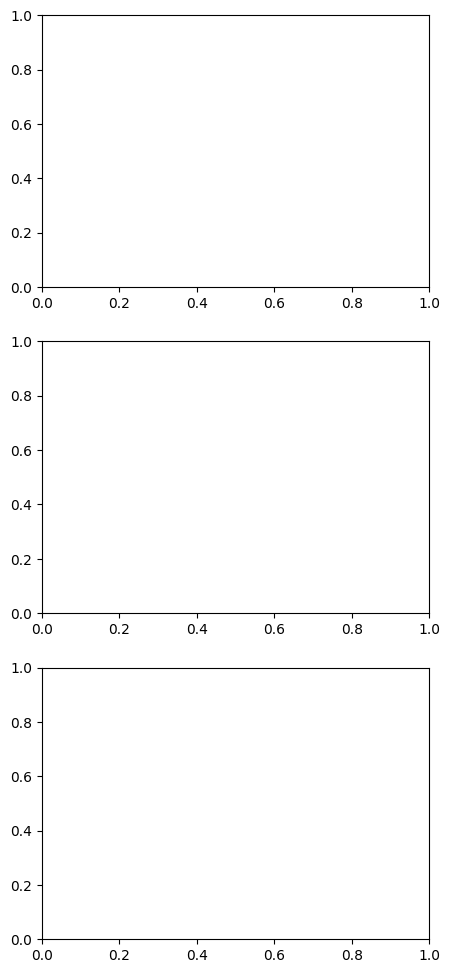

<Figure size 600x800 with 0 Axes>

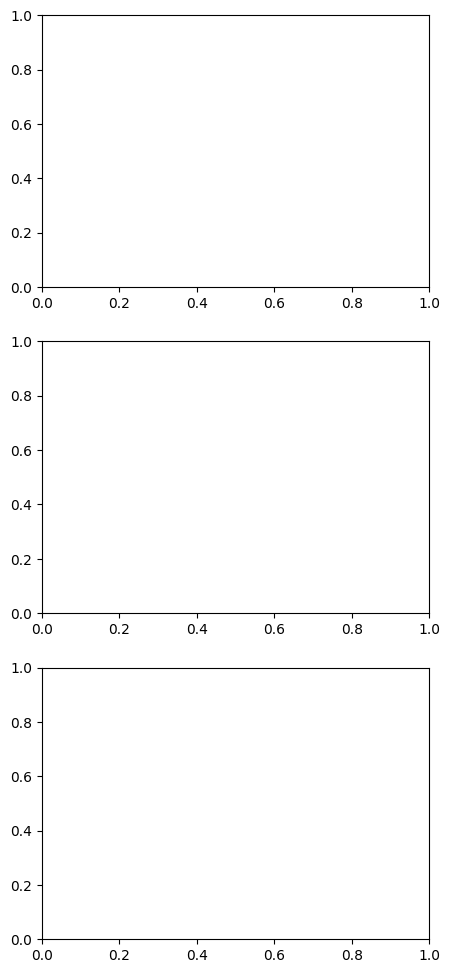

<Figure size 600x800 with 0 Axes>

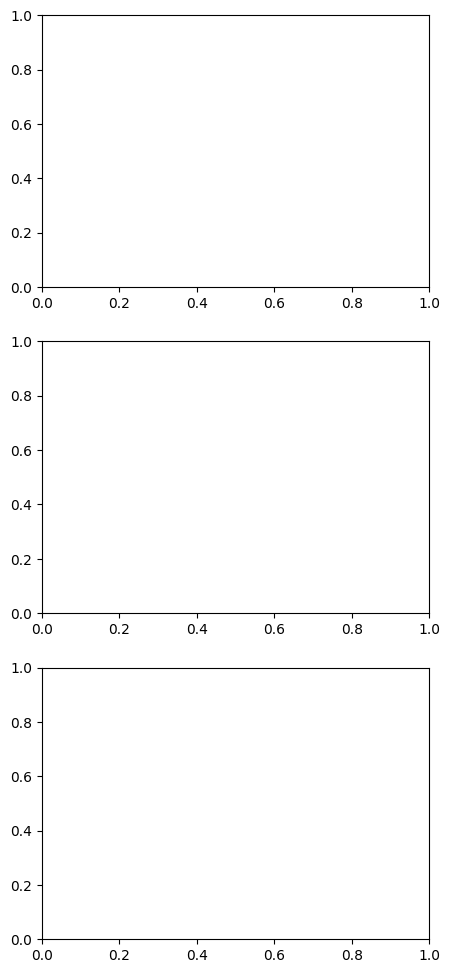

<Figure size 600x800 with 0 Axes>

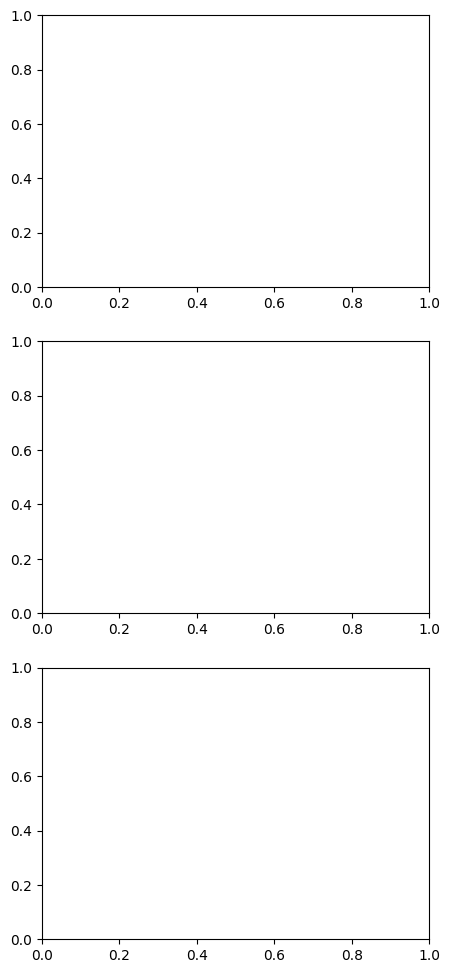

<Figure size 600x800 with 0 Axes>

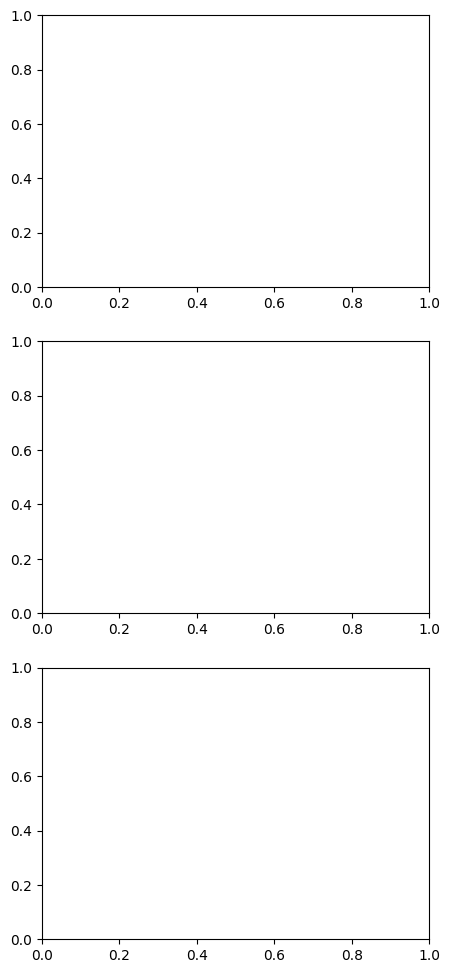

<Figure size 600x800 with 0 Axes>

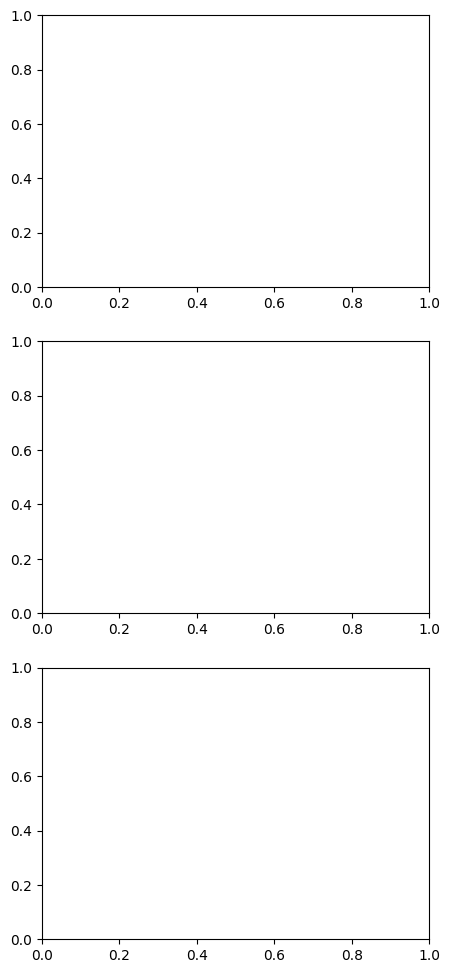

<Figure size 600x800 with 0 Axes>

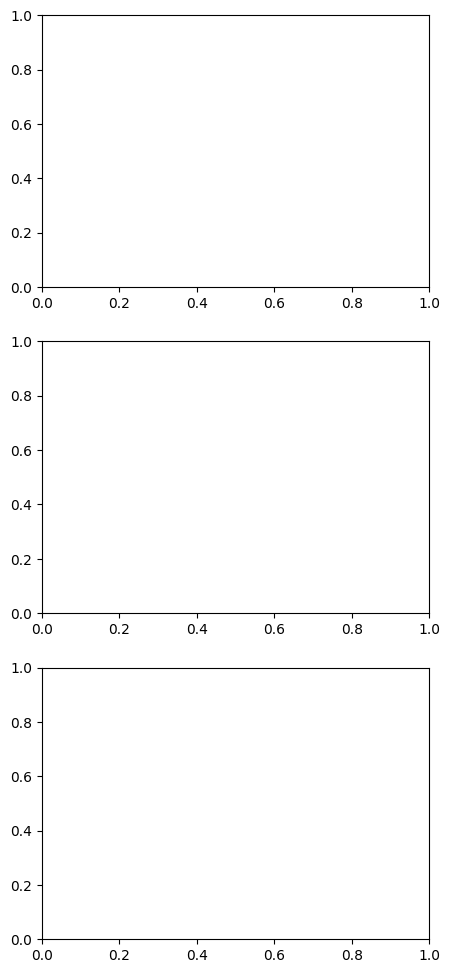

<Figure size 600x800 with 0 Axes>

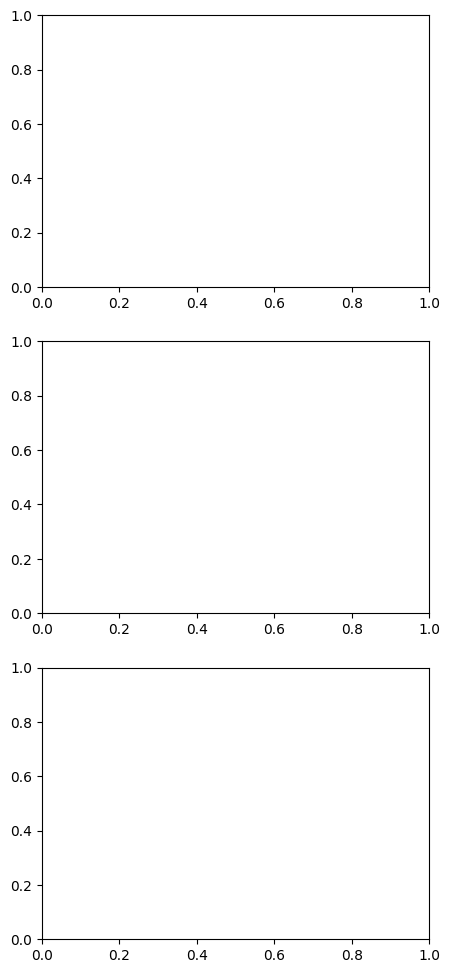

<Figure size 600x800 with 0 Axes>

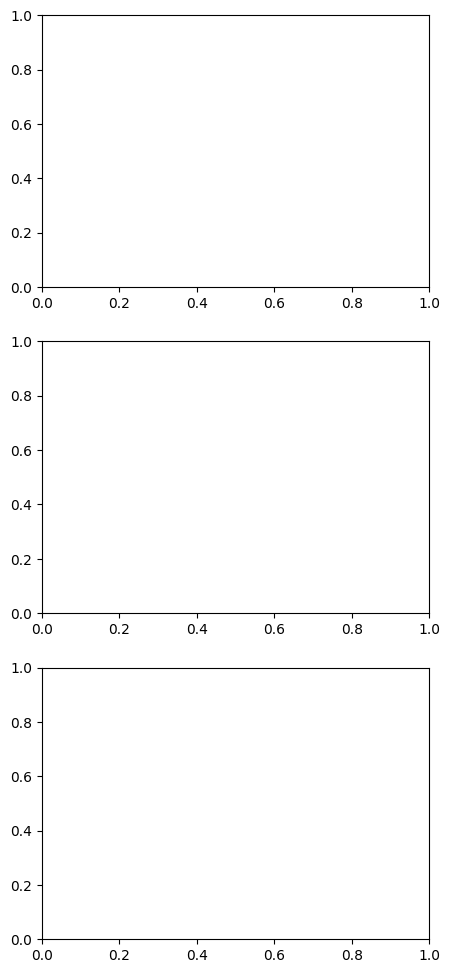

<Figure size 600x800 with 0 Axes>

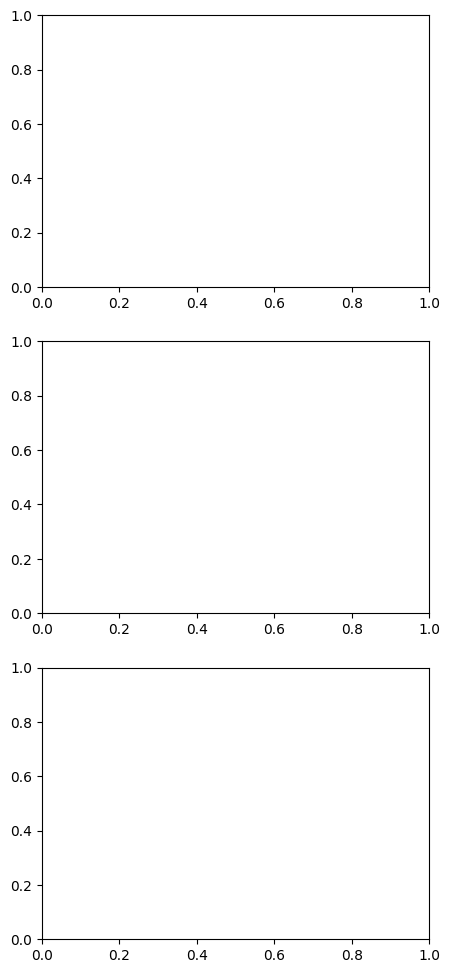

<Figure size 600x800 with 0 Axes>

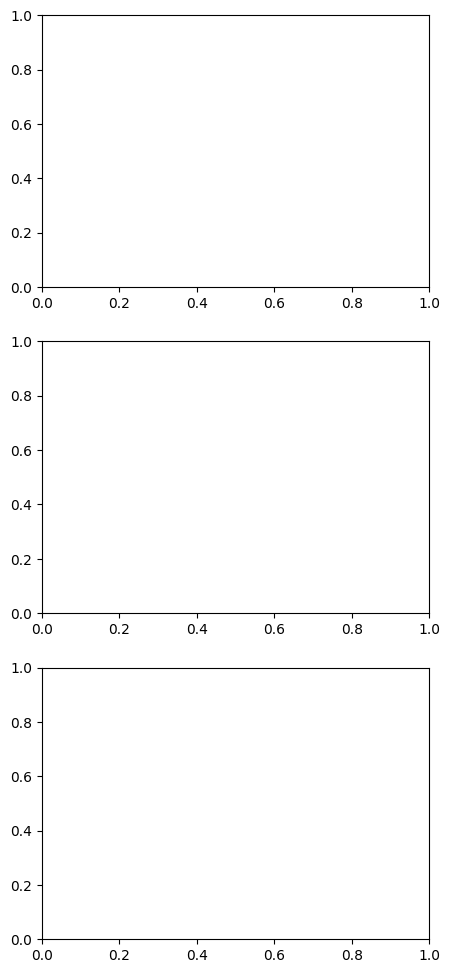

<Figure size 600x800 with 0 Axes>

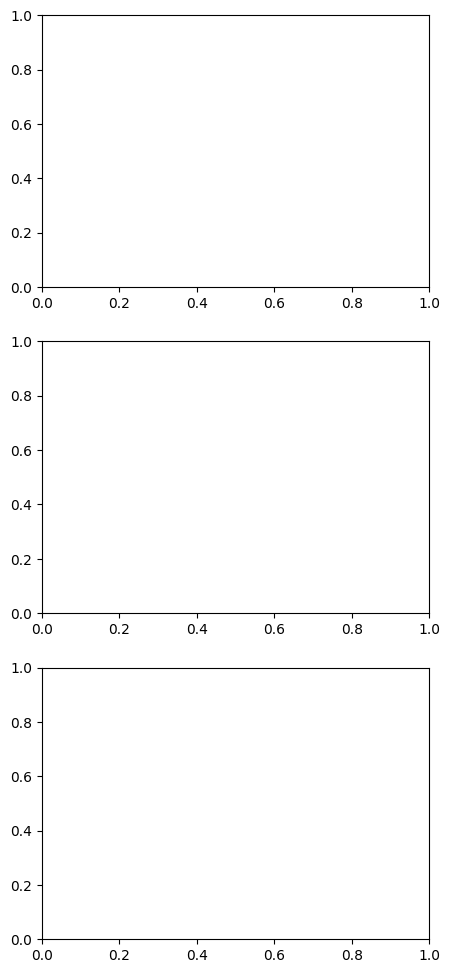

<Figure size 600x800 with 0 Axes>

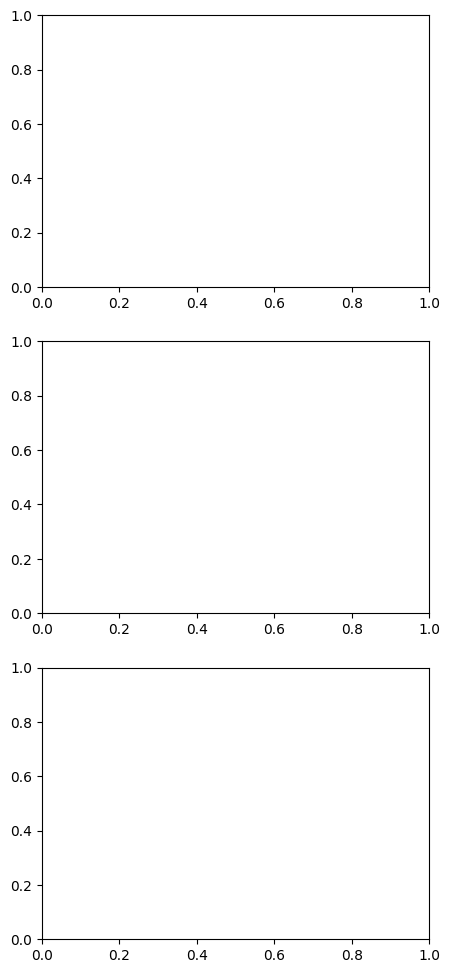

<Figure size 600x800 with 0 Axes>

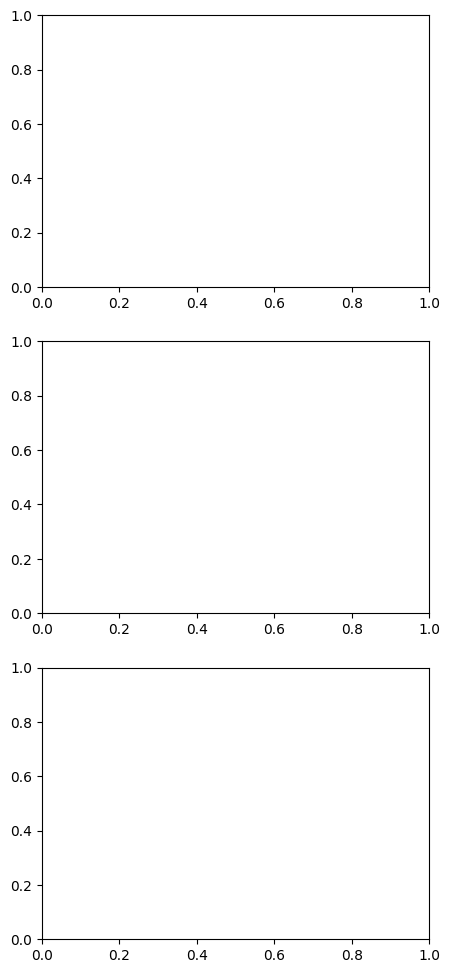

<Figure size 600x800 with 0 Axes>

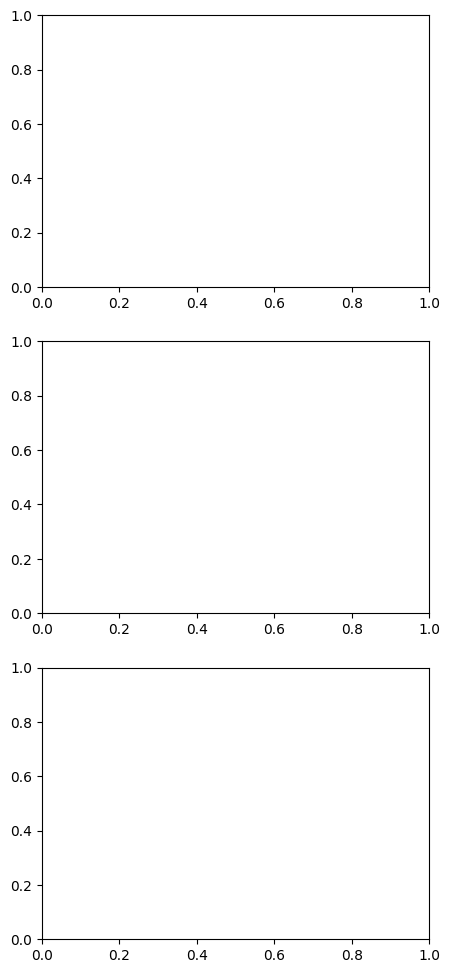

<Figure size 600x800 with 0 Axes>

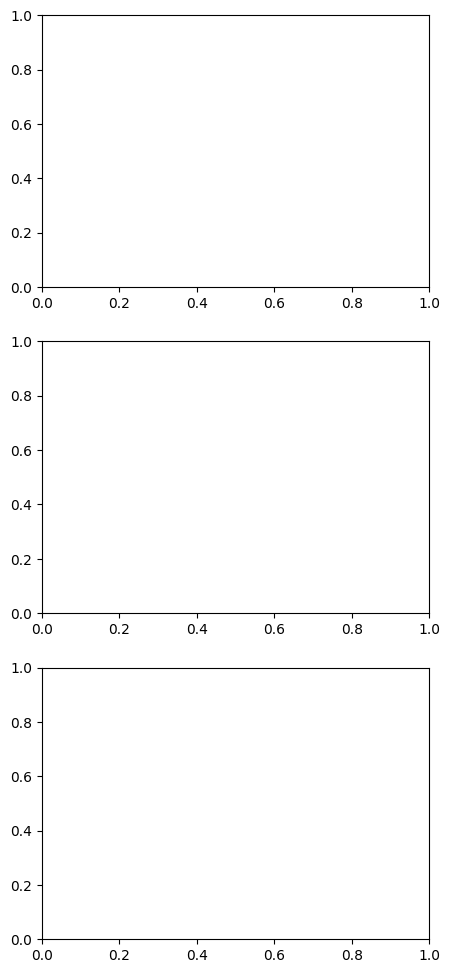

<Figure size 600x800 with 0 Axes>

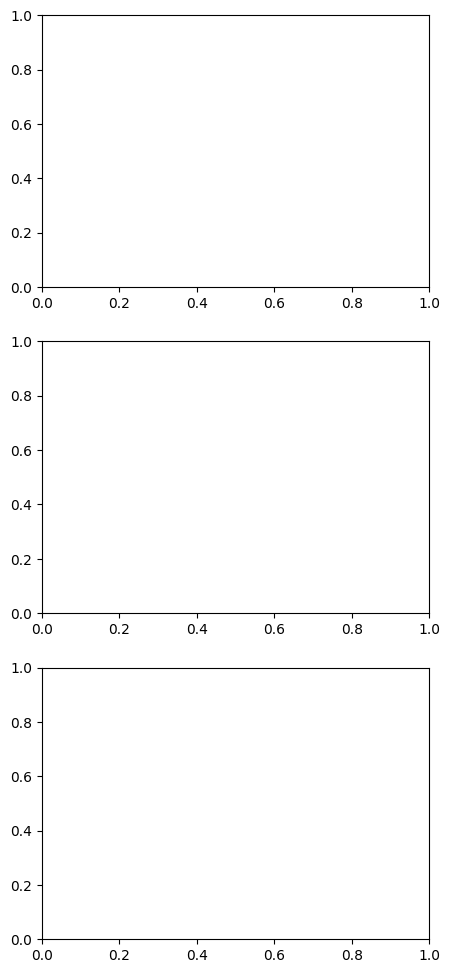

<Figure size 600x800 with 0 Axes>

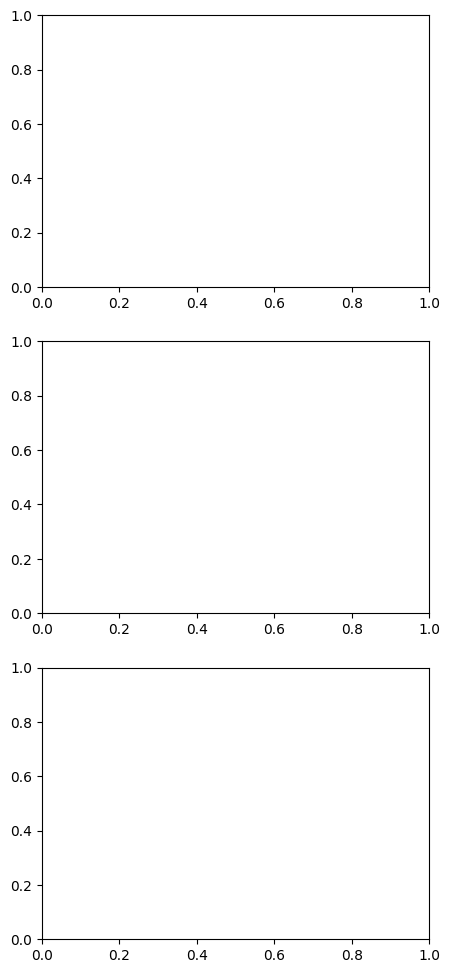

<Figure size 600x800 with 0 Axes>

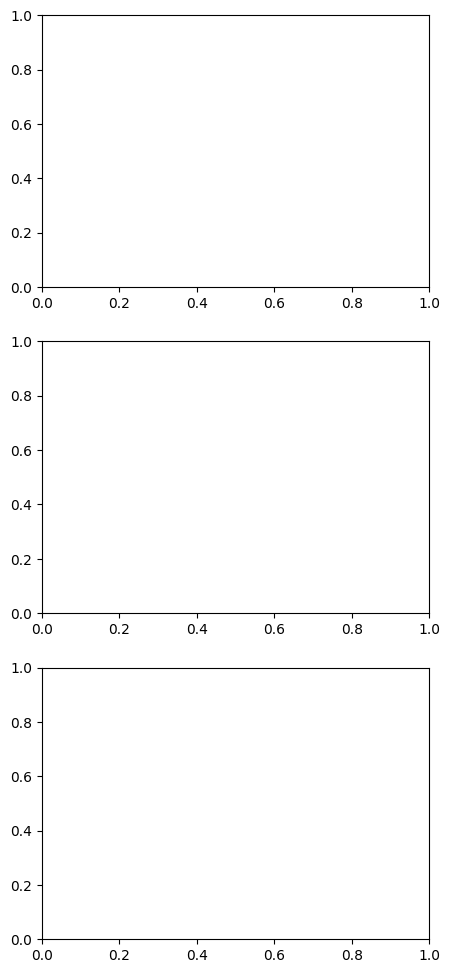

<Figure size 600x800 with 0 Axes>

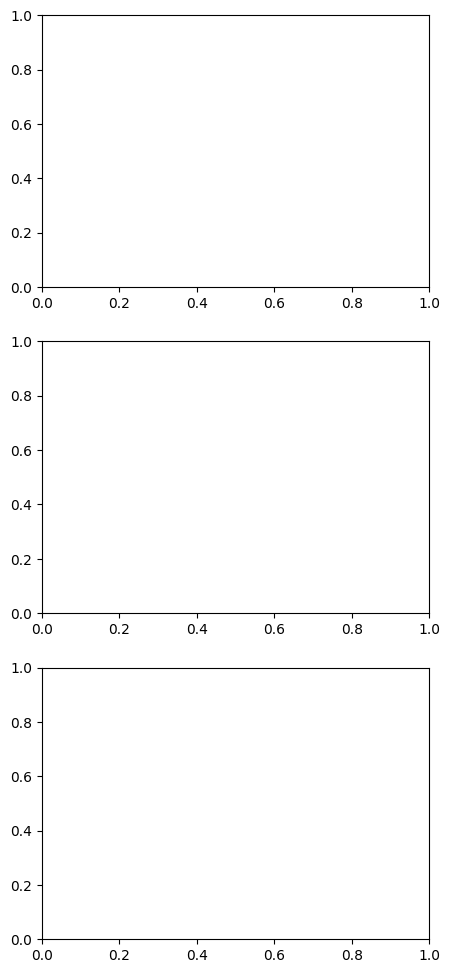

<Figure size 600x800 with 0 Axes>

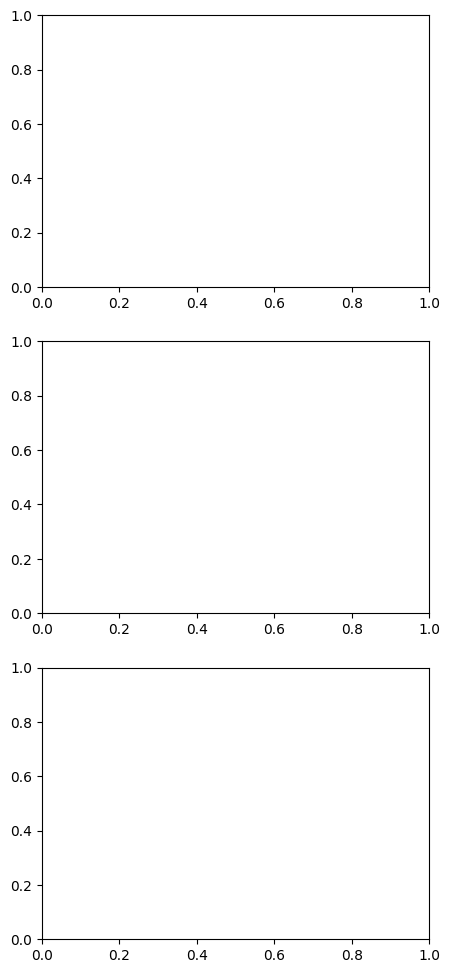

<Figure size 600x800 with 0 Axes>

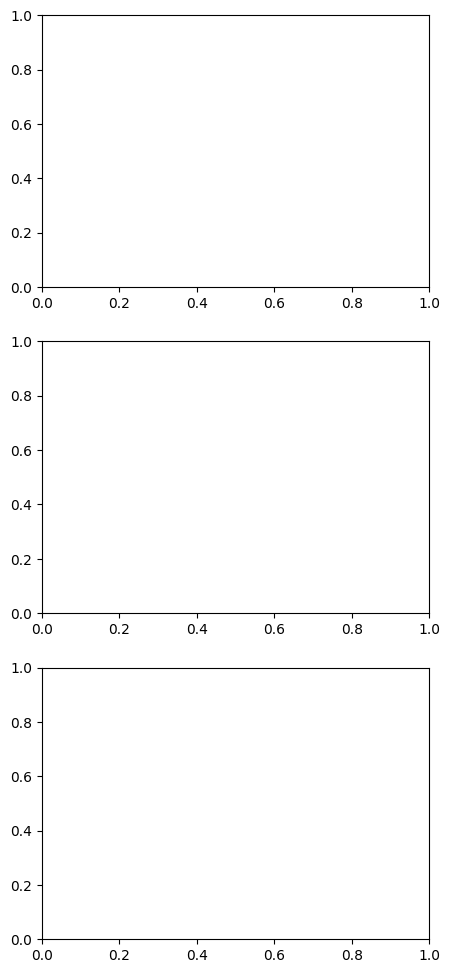

<Figure size 600x800 with 0 Axes>

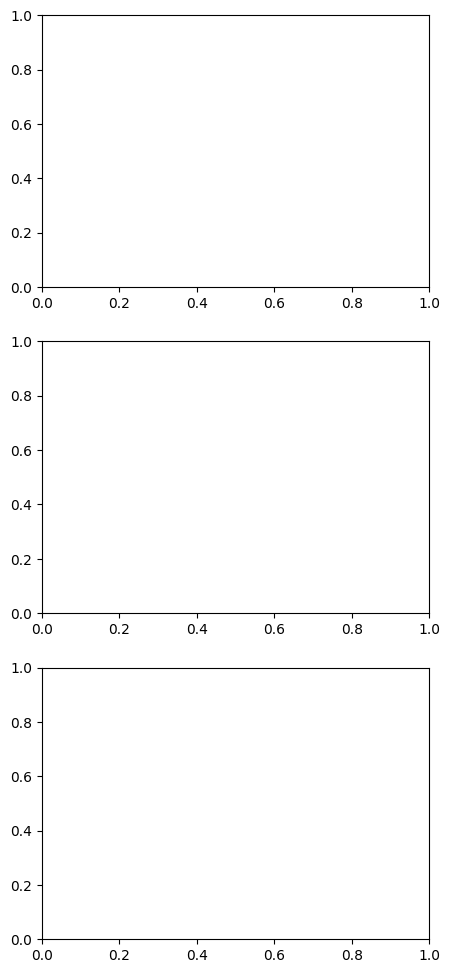

<Figure size 600x800 with 0 Axes>

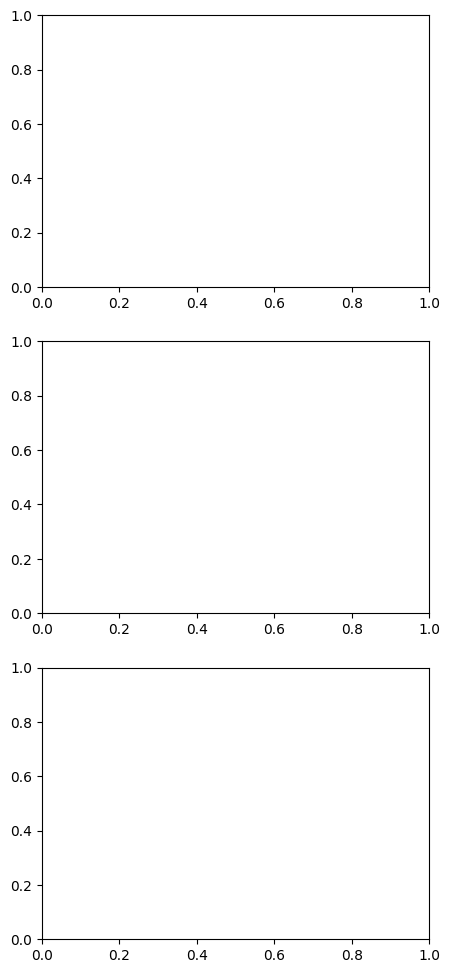

<Figure size 600x800 with 0 Axes>

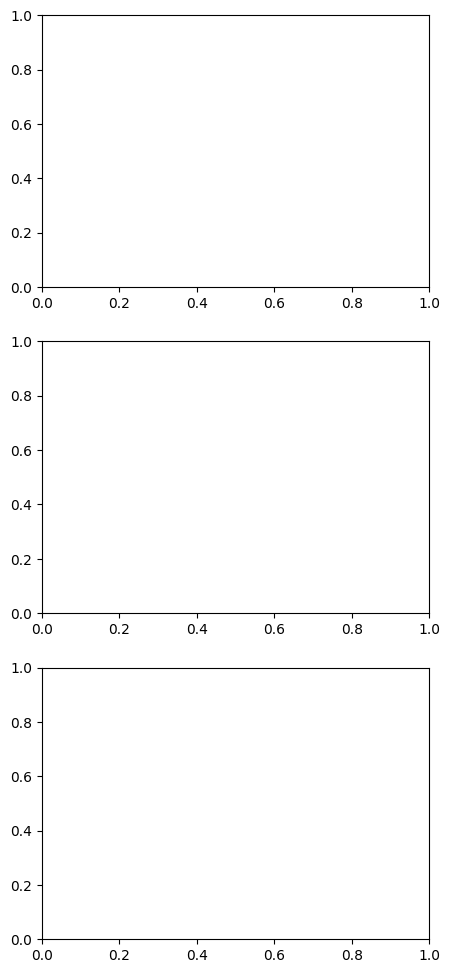

<Figure size 600x800 with 0 Axes>

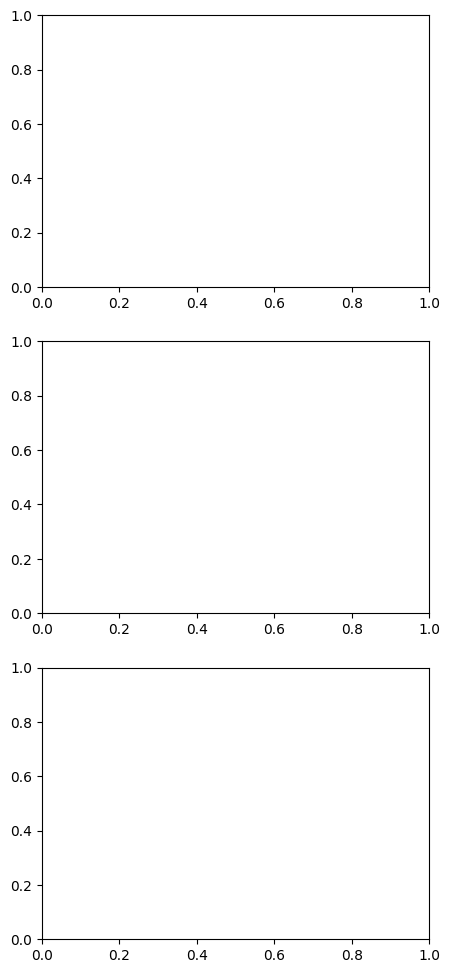

<Figure size 600x800 with 0 Axes>

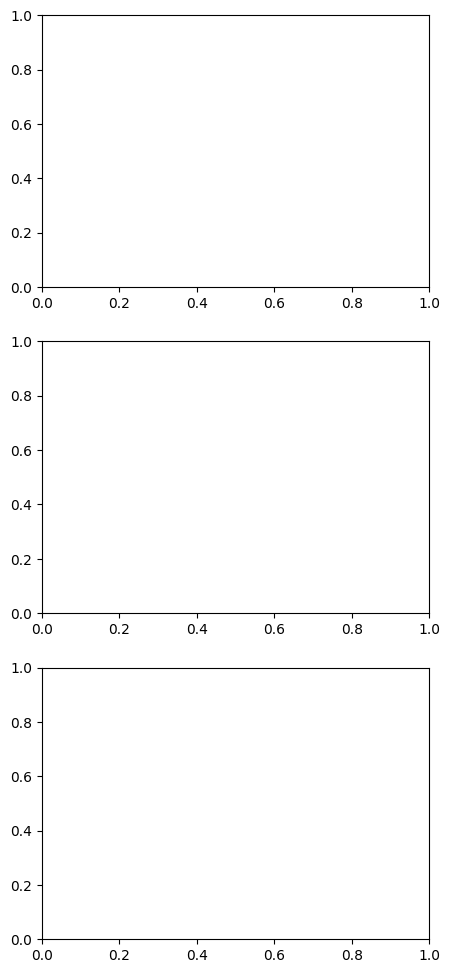

<Figure size 600x800 with 0 Axes>

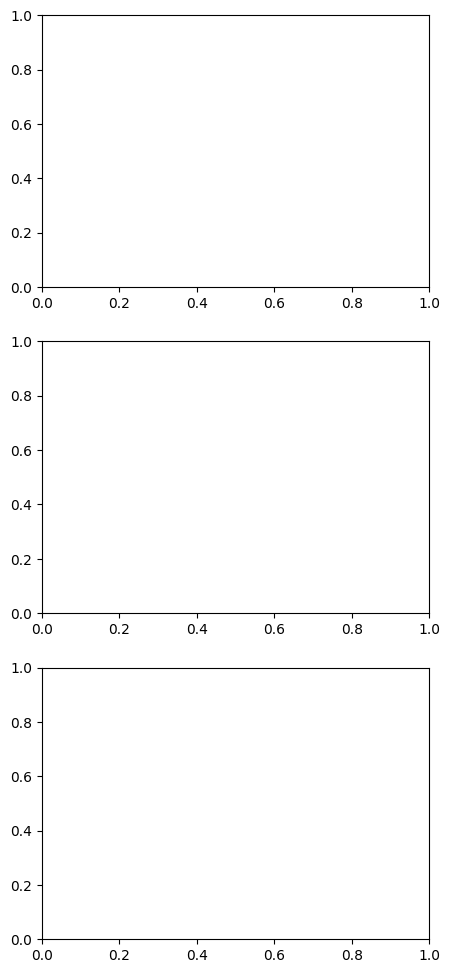

<Figure size 600x800 with 0 Axes>

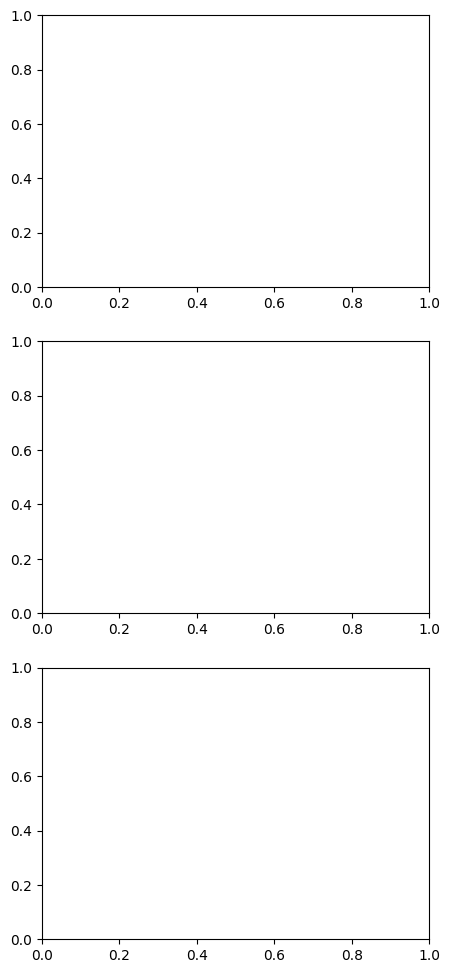

<Figure size 600x800 with 0 Axes>

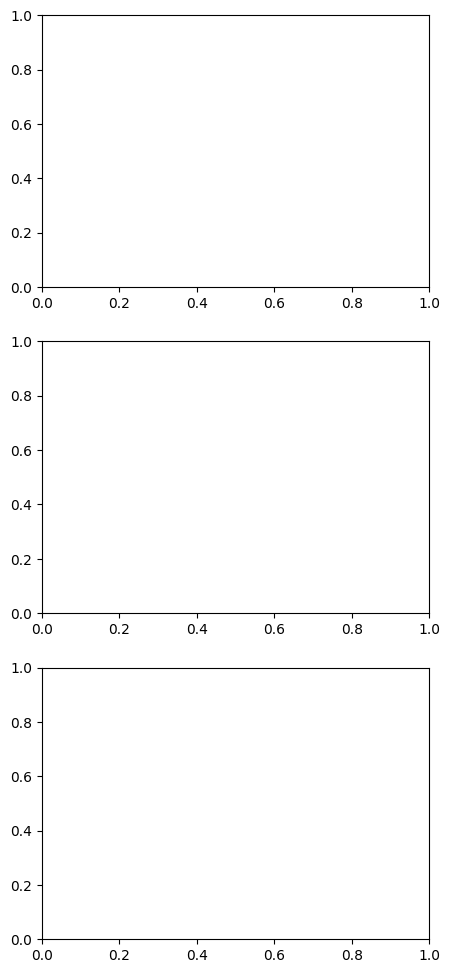

<Figure size 600x800 with 0 Axes>

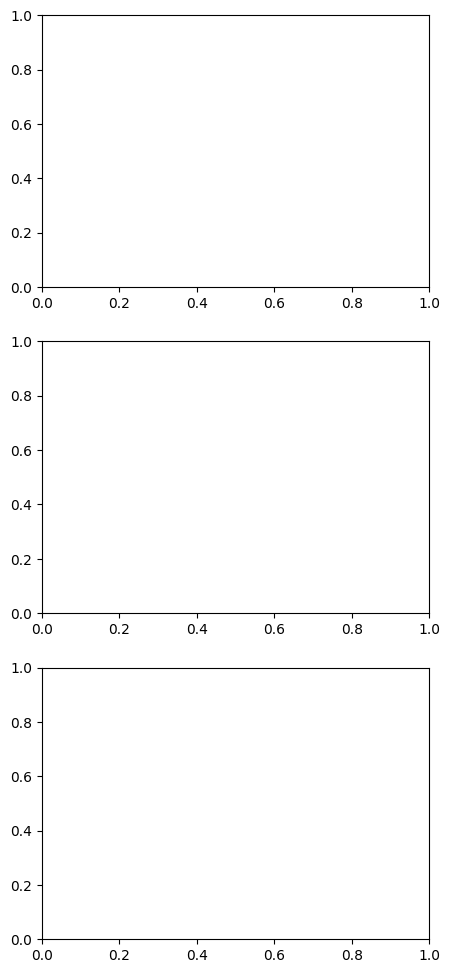

<Figure size 600x800 with 0 Axes>

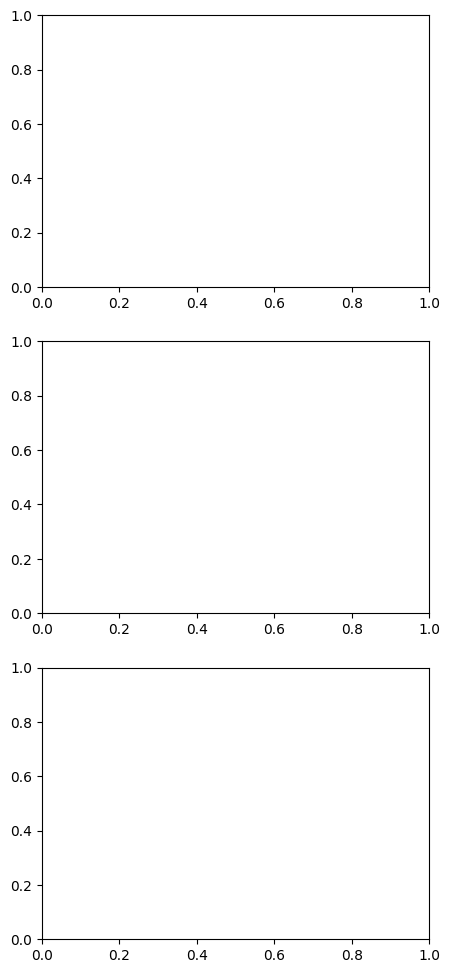

<Figure size 600x800 with 0 Axes>

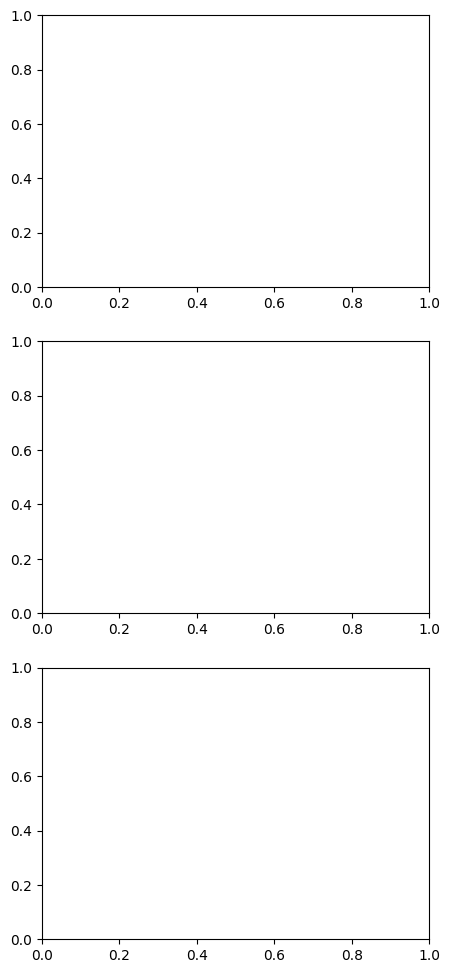

<Figure size 600x800 with 0 Axes>

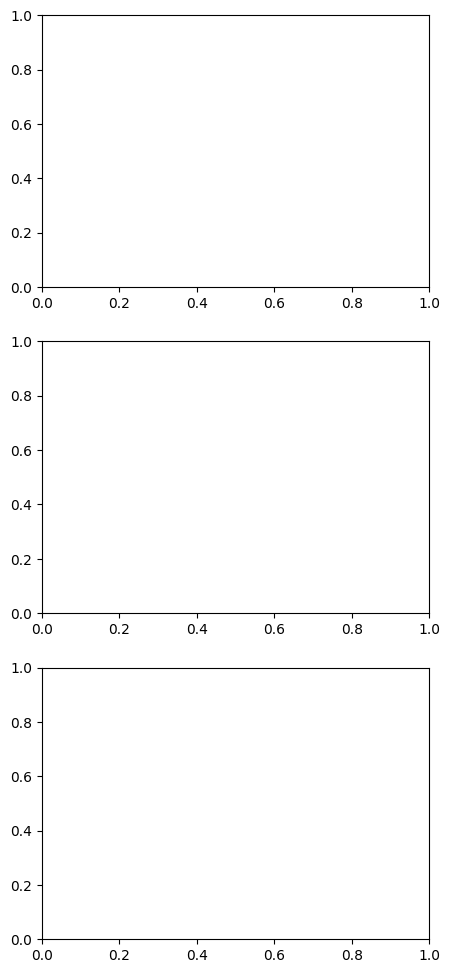

<Figure size 600x800 with 0 Axes>

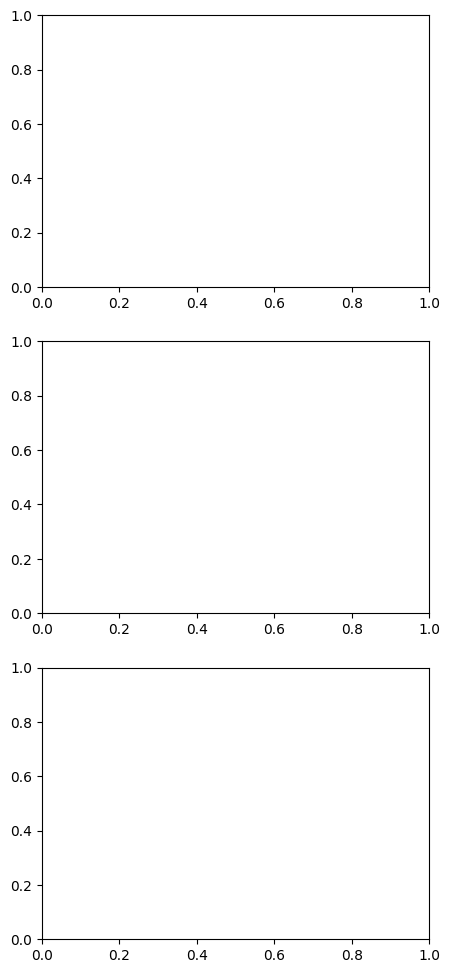

<Figure size 600x800 with 0 Axes>

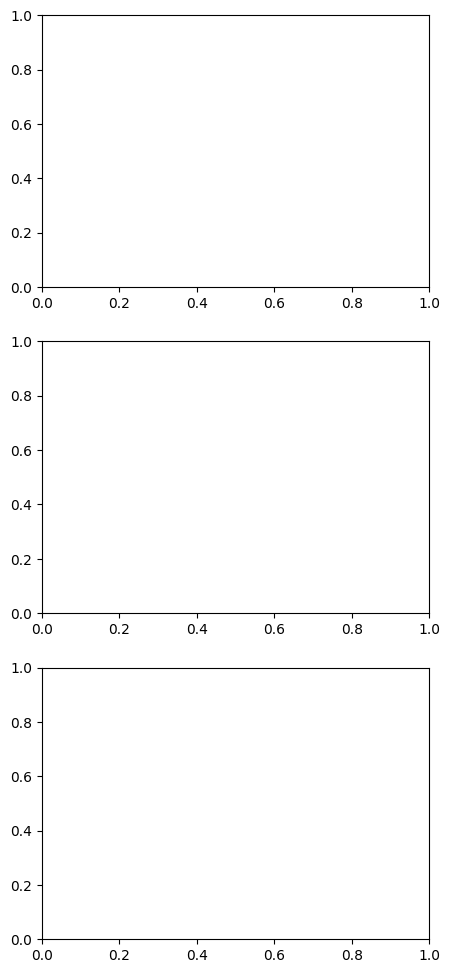

<Figure size 600x800 with 0 Axes>

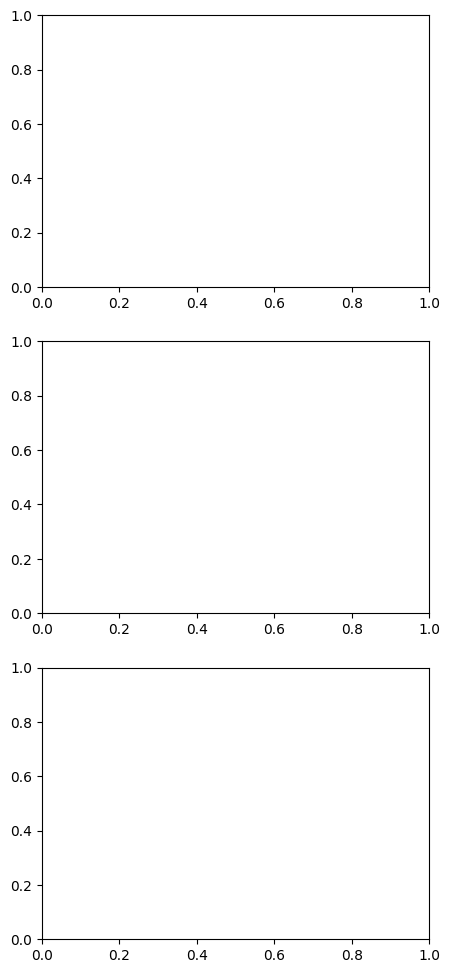

<Figure size 600x800 with 0 Axes>

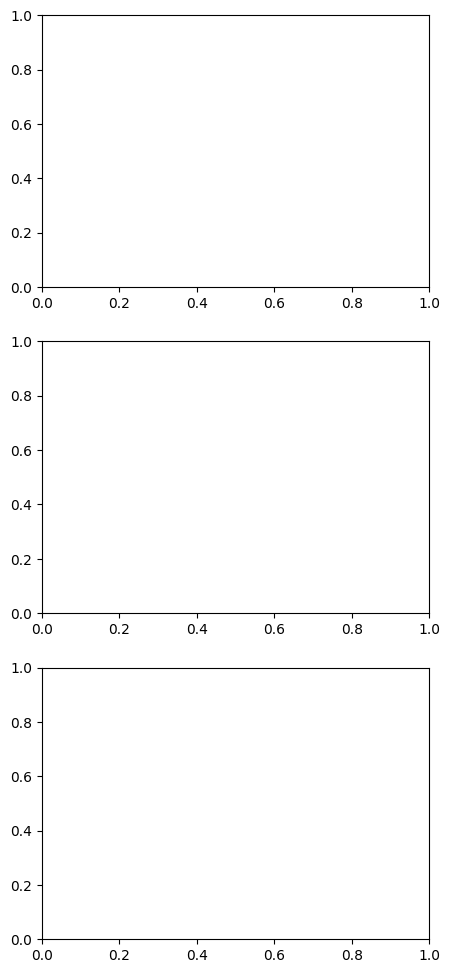

<Figure size 600x800 with 0 Axes>

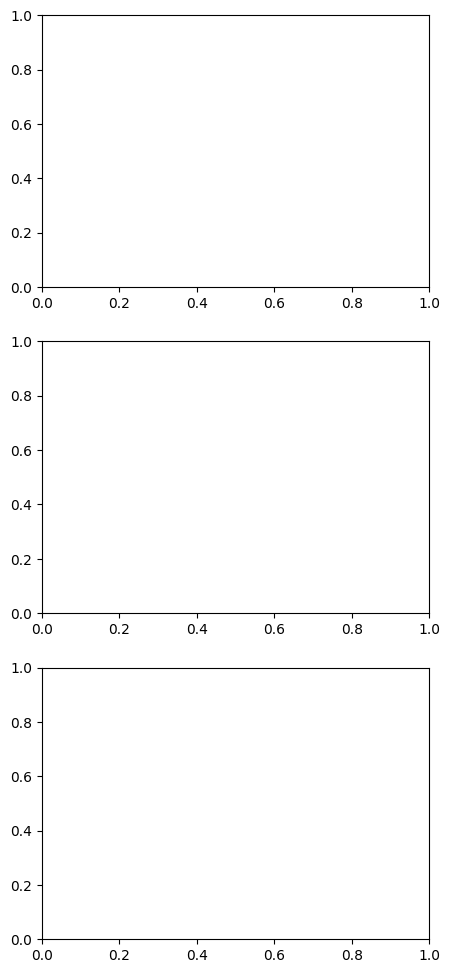

<Figure size 600x800 with 0 Axes>

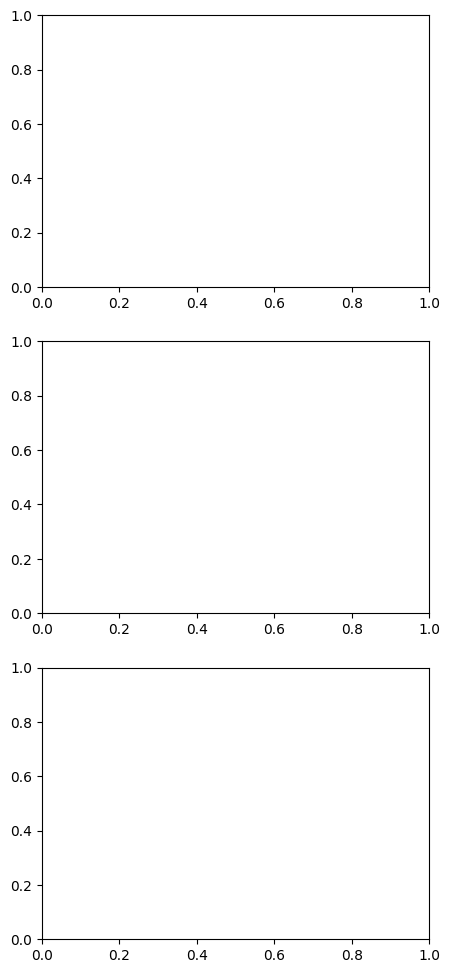

<Figure size 600x800 with 0 Axes>

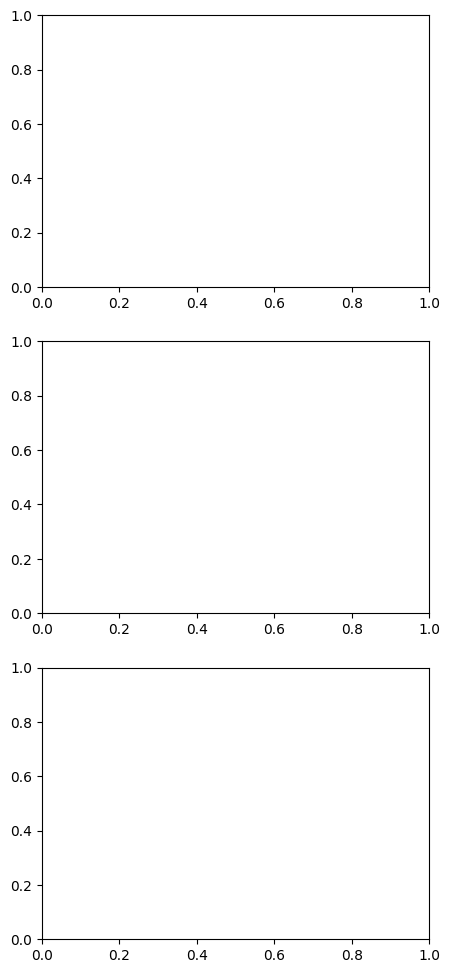

<Figure size 600x800 with 0 Axes>

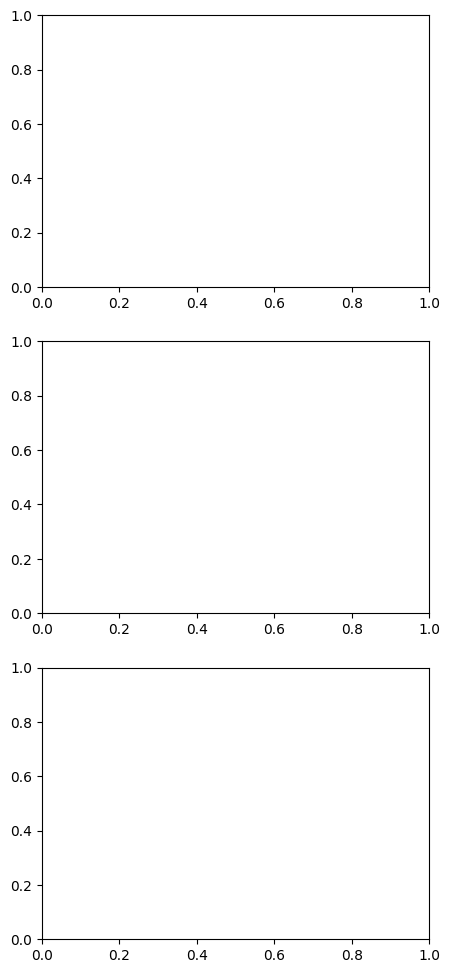

<Figure size 600x800 with 0 Axes>

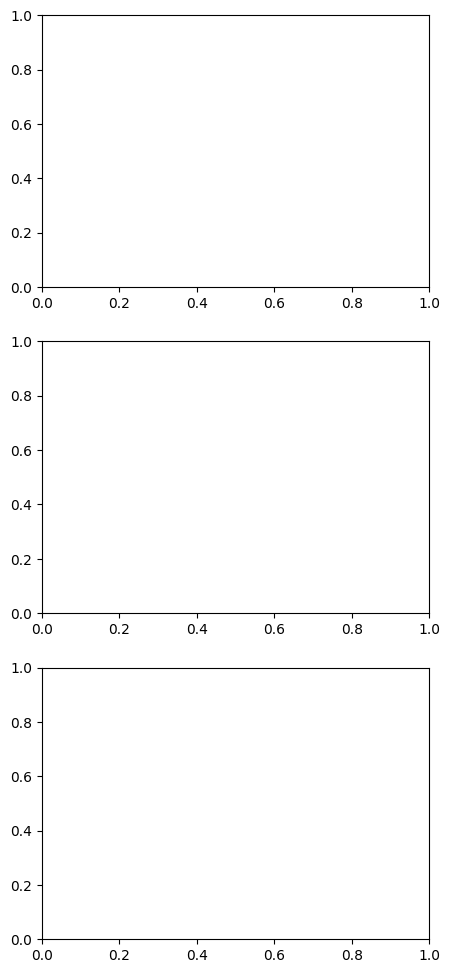

<Figure size 600x800 with 0 Axes>

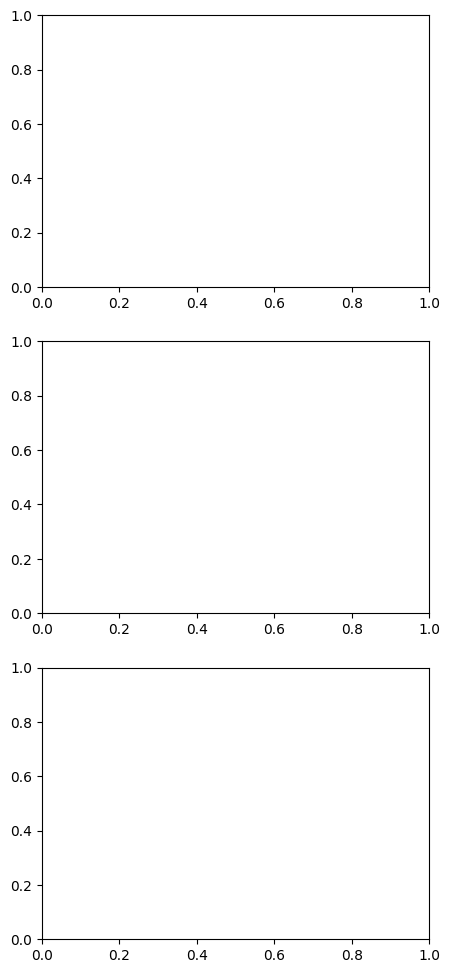

<Figure size 600x800 with 0 Axes>

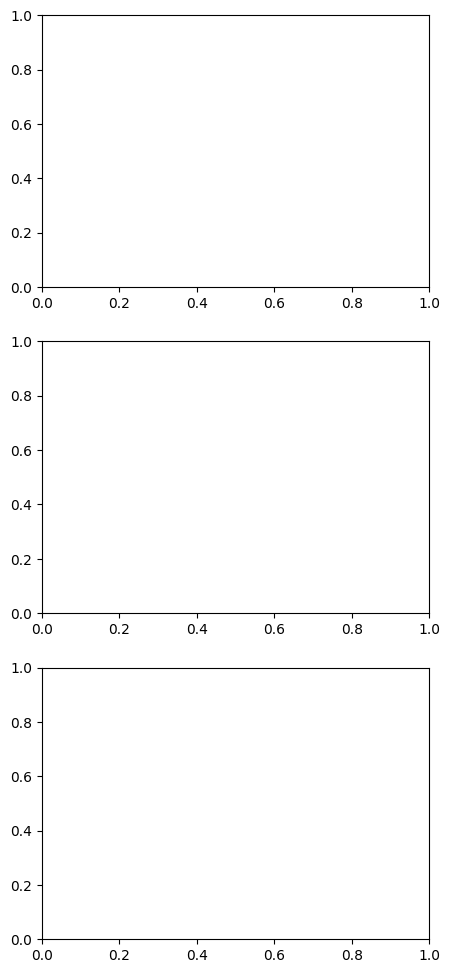

<Figure size 600x800 with 0 Axes>

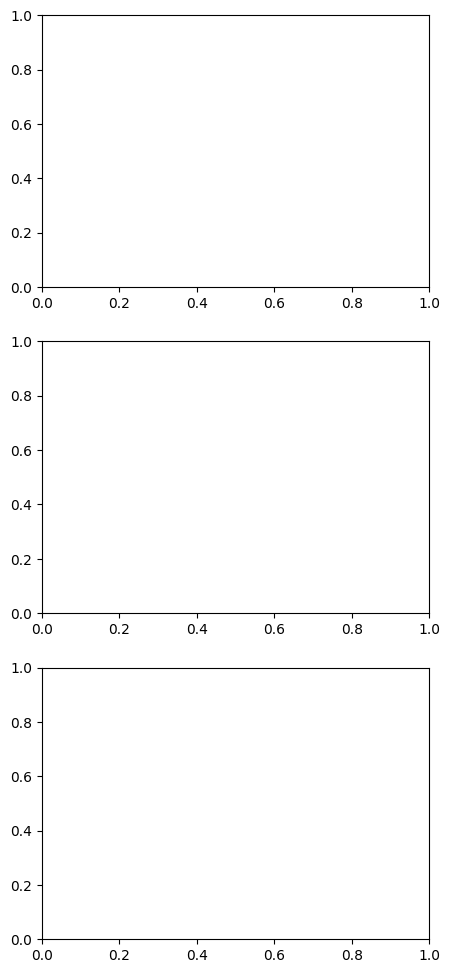

<Figure size 600x800 with 0 Axes>

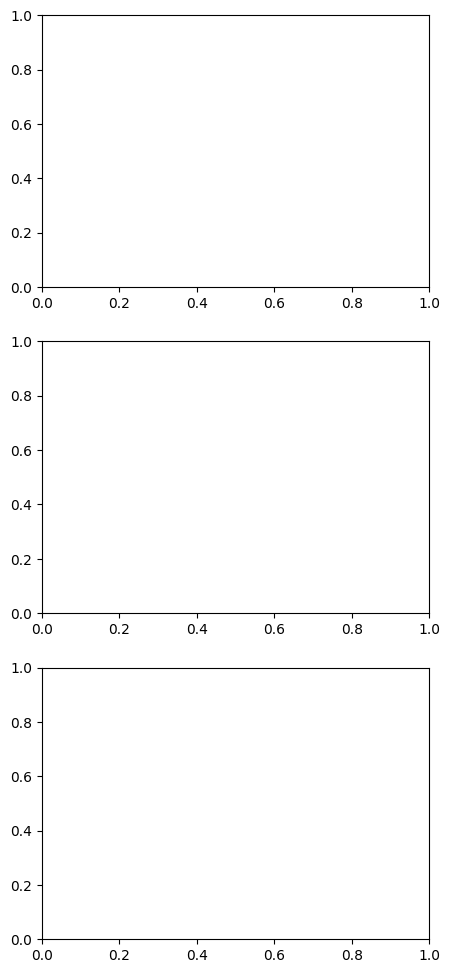

In [ ]:
Z = ZombieApocolypse(n=100, k=3)
make_gif(Z, steps=100)